# Comparative Analysis of Classical and Quantum Kernel Embeddings for Regime Identification in Simulated Silicon Quantum Dots

**Affiliation:** This research is developed as part of the **QOSF (Quantum Open Source Foundation) Mentorship Program**.

## 1. Project Overview
This notebook marks the beginning of a 12-week research journey at the intersection of **Quantum Hardware Simulation** and **Applied Quantum Machine Learning (QML)**. 

The core objective is to build a complete, ground-up pipeline that connects realistic device physics—simulated via **QTCAD**—with modern machine learning classification methods. This project focuses on the **methodological integration** of physical simulation and quantum kernel methods within the framework of the QOSF mentorship.

### Key Research Goals:
* **Data Generation:** Simulating silicon double quantum dots to extract charge stability diagrams.
* **Classical Baseline:** Establishing a reference using SVM with an RBF kernel.
* **Quantum Extension:** Implementing a simulated quantum kernel using the `ZZFeatureMap`.
* **Geometric Analysis:** Understanding how decision boundaries shift between classical and quantum feature spaces.

---

## 2. Learning Path & Evolution
As an early-stage researcher transitioning into quantum technologies, this notebook serves as a living document of my technical growth. 

**Current Phase:** Level 1 - Physical Problem Understanding & Data Encoding.


## 3. Technical Deep Dive: Data Encoding Strategies
Before we can apply any Quantum Kernel, we must address a fundamental question: **How do we "translate" classical data (like gate voltages from QTCAD) into a quantum state?** This process is known as **Data Encoding** or **Feature Mapping**.

### 3.1 Why is this relevant to Silicon Quantum Dots?
Our stability diagrams consist of voltage coordinates $(V_{g1}, V_{g2})$. To process these in a quantum simulator, we need to map these coordinates into the parameters of a quantum circuit, usually as rotation angles of gates.

### 3.2 Types of Encoding:
* **Basis Encoding:** Mapping binary strings to computational basis states $|x\rangle$.
* **Angle Encoding:** Using data values as rotation angles ($R_x, R_y, R_z$) for qubits. Efficient as it requires $n$ qubits for $n$ features.
* **Amplitude Encoding:** Storing data in the amplitudes of a quantum state (highly efficient but complex to implement).

### 3.3 Basis Encoding: The Discrete Approach
Basis encoding maps a classical $P$-bit string directly into a computational basis state. If we have a feature $x$ represented as a $P$-bit binary string $(b_1, b_2, ..., b_P)$, the corresponding quantum state is $|x\rangle = |b_1, b_2, ..., b_P\rangle$.

**Example:** Encoding the vector $(5, 7, 0)$ using 4 bits per feature.
* $5 \rightarrow 0101$ | $7 \rightarrow 0111$ | $0 \rightarrow 0000$

The global state for a 12-qubit system is: $|0101 \text{ } 0111 \text{ } 0000\rangle$.

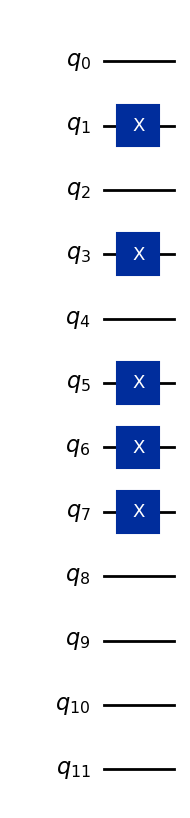

In [10]:
from qiskit import QuantumCircuit
# Datapoints to encode (simulating discrete feature representation)
x,y,z = 5,7,0 

# Data point to encode
x = 5  # binary: 0101
y = 7  # binary: 0111
z = 0  # binary: 0000

# Convert each to 4-bit binary list
x_bits = [int(b) for b in format (x, "04b")]
y_bits = [int(b) for b in format (y, "04b")]
z_bits = [int(b) for b in format (z, "04b")]

all_bits = x_bits+y_bits+z_bits # [0,1,0,1,0,1,1,1,0,0,0,0]
qc_basis = QuantumCircuit(12)

# Apply X-gates where the bit is 1
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc_basis.x(idx)


qc_basis.draw("mpl")

**Check your understanding**
Write code to encode the first vector in our example data set:
x =(4,8,5) using basis encoding.

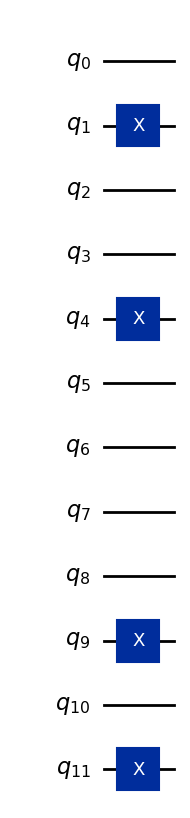

In [9]:
x,y,z = 4,8,5 

# Data point to encode
x = 4  # binary: 0100
y = 8  # binary: 1000
z = 5  # binary: 0101

# Convert each to 4-bit binary list
x_bits = [int(b) for b in format (x, "04b")]
y_bits = [int(b) for b in format (y, "04b")]
z_bits = [int(b) for b in format (z, "04b")]

all_bits = x_bits+y_bits+z_bits  # [0,1,0,0,1,0,0,0,0,1,0,1]
qc_basis = QuantumCircuit(12)

# Apply X-gates where the bit is 1
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc_basis.x(idx)


qc_basis.draw("mpl")

### 3.4  Amplitude Encoding: High-Density Compression

Amplitude encoding stores a normalized $N$-dimensional classical data vector $x$ into the amplitudes of a quantum state:

$$|\psi_x\rangle = \frac{1}{\alpha} \sum_{i=1}^{N} x_i |i\rangle$$

#### Key Characteristics:

* **Mathematical Constraint**: The state must be normalized according to quantum mechanics: $\sum_{i=1}^{N} |x_i|^2 = |\alpha|^2$.
* **Qubit Efficiency**: It offers an exponential saving in space, requiring only $n \ge \log_2(N)$ qubits to encode $N$ features.
* **Padding**: If the number of features $N$ is not a power of 2, we choose $n$ such that $2^n \ge N$ and pad the vector with zeros.
* **The Trade-off**: Preparing these arbitrary states is generally inefficient, often requiring a number of CNOT gates that scale exponentially with the number of qubits.

---

#### Implementation Example: Encoding a Feature Vector
The following code demonstrates how to automate the normalization and generate a quantum circuit using Qiskit's `initialize` function.

---

#### Relevance to the Silicon QD Project
While **Amplitude Encoding** is mathematically elegant, the Silicon Quantum Dot project primarily utilizes **Angle/Phase Encoding** via the `ZZFeatureMap`.

**Why?**

1.  **Complexity**: Amplitude encoding requires complex state preparation that is highly susceptible to noise in NISQ devices.
2.  **Interpretability**: Angle-based rotations allow for a more direct geometric interpretation of the relationship between gate voltages ($V_{g1}, V_{g2}$) and the resulting quantum state.

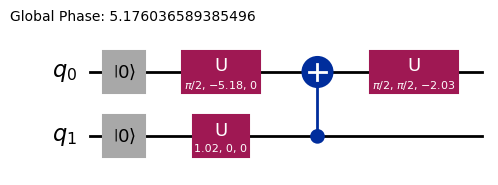

In [13]:
import math

desired_state = [ 
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]

qc = QuantumCircuit(2)
qc.initialize(desired_state, [0,1])

qc.decompose(reps=5).draw(output="mpl")

**Check your understanding** 

Write down the normalized state for encoding the following vector (made of two vectors from our example dataset):

x = (9,8,6,2,9,2)

**Normalizing**

$$
|\psi\rangle = \frac{1}{16.43} \left( 9|000\rangle + 8|001\rangle + 6|010\rangle + 2|011\rangle + 9|100\rangle + 2|101\rangle + 0|110\rangle + 0|111\rangle \right)
$$

Write code to create a circuit that loads these data features using amplitude encoding.

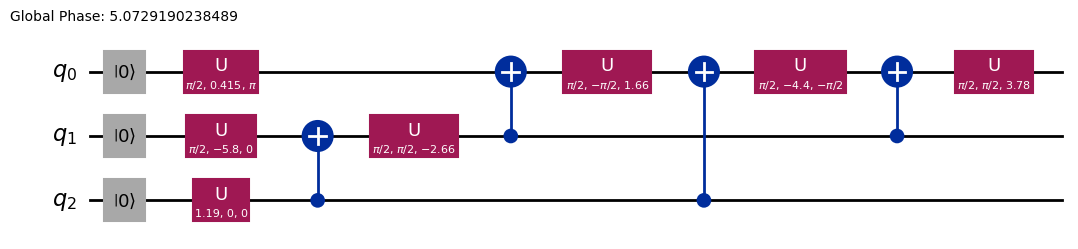

In [19]:
import math

desired_state = [
    1/math.sqrt(270) * 9,
    1/math.sqrt(270) * 8,
    1/math.sqrt(270) * 6,
    1/math.sqrt(270) * 2,
    1/math.sqrt(270) * 9,
    1/math.sqrt(270) * 2,
    0,
    0,
]

qc = QuantumCircuit(3)
qc.initialize(desired_state, [0,1,2])

qc.decompose(reps=5).draw(output="mpl")

**Optimizing the code**

Created 4-qubit circuit from 15-dimensional data


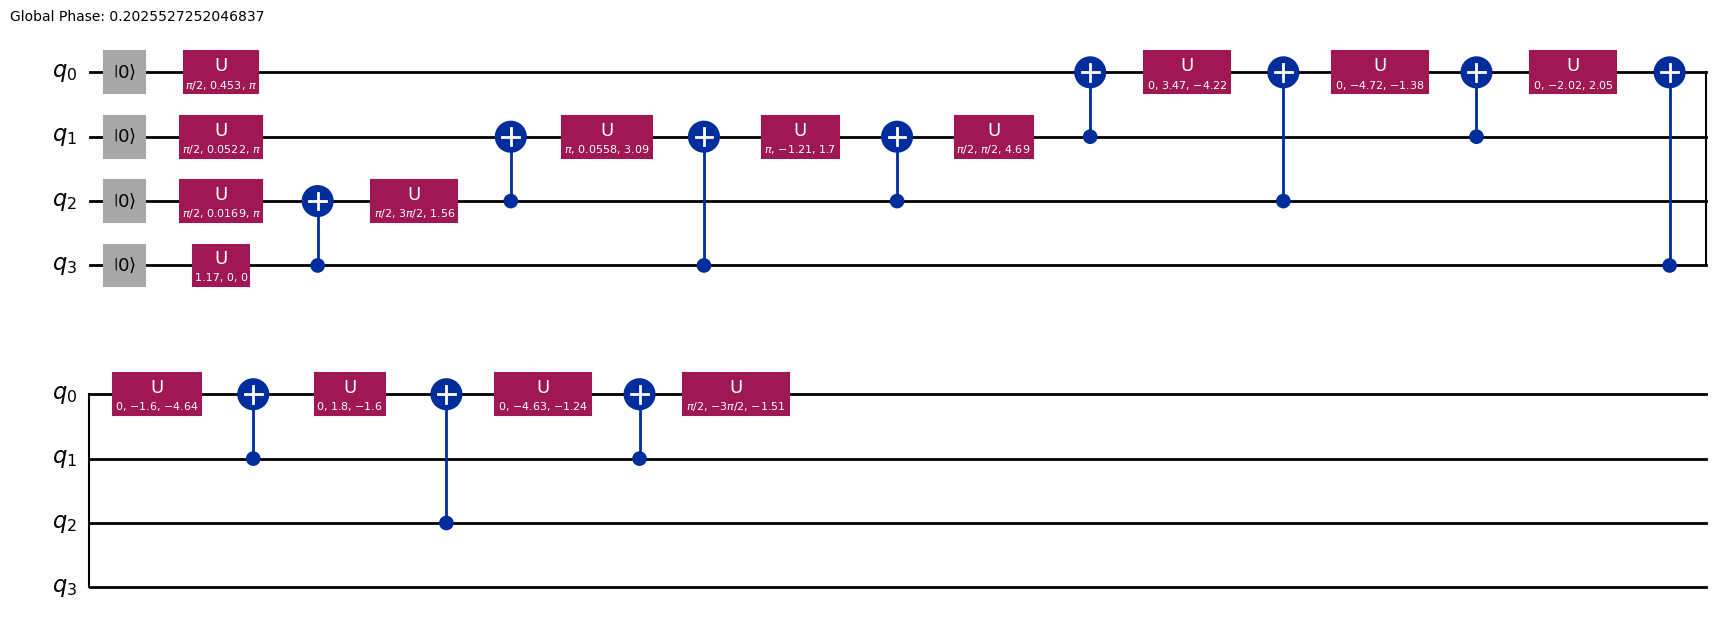

In [21]:
import numpy as np
from qiskit import QuantumCircuit

def data_to_circuit(data):
    """Convert classical data vector to initialized quantum circuit."""
    # Calculate qubits and pad
    n_qubits = int(np.ceil(np.log2(len(data))))
    padded = data + [0] * (2**n_qubits - len(data))
    
    # Normalize
    state = np.array(padded) / np.linalg.norm(padded)
    
    # Create circuit
    qc = QuantumCircuit(n_qubits)
    qc.initialize(state, range(n_qubits))
    
    print(f"Created {n_qubits}-qubit circuit from {len(data)}-dimensional data")
    return qc

# Usage
init_list = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0, 3, 7, 5]
circuit = data_to_circuit(init_list)
circuit.decompose(reps=5).draw(output="mpl")



### 3.5 Angle Encoding

Angle encoding is a fundamental technique used in many Quantum Machine Learning (QML) models, specifically those utilizing Pauli Feature Maps like Quantum Support Vector Machines (QSVMs) and Variational Quantum Circuits (VQCs). It is closely related to phase encoding and dense angle encoding.

 #### Core Mechanism

In this method, data is encoded as a rotation angle θ away from the Z-axis. While any combination of rotations can be used, $R_Y$ gates are most common in the literature. When encoding a single feature $x_k^{(j)}$ from a dataset into a single qubit, the transformation is:

$$|x_k^{(j)}\rangle = R_Y(\theta = x_k^{(j)})|0\rangle = \cos\left(\frac{x_k^{(j)}}{2}\right)|0\rangle + \sin\left(\frac{x_k^{(j)}}{2}\right)|1\rangle$$

Alternatively, $R_X(\theta)$ gates can be used, though this introduces a complex relative phase compared to $R_Y$.

#### Key Characteristics

Angle encoding differs from other methods (like Amplitude or Basis encoding) in several critical ways:

- **Qubit Mapping**: Each feature value is mapped to a corresponding qubit ($x_k^{(j)} \rightarrow Q_k$), resulting in a product state.
- **Sequential Encoding**: Only one numerical value is encoded per qubit at a time.
- **Qubit Requirements**: Typically, $n$ qubits are required for $N$ data features ($n \leq N$), often where $n = N$.
- **Constant Depth**: The resulting circuit has a constant depth (typically depth 1 before transpilation).
- **Hardware Compatibility**: Its shallow circuit depth makes it exceptionally well-suited for current (NISQ) quantum hardware.
- **Real-Valued States**: Using $R_Y$ rotations creates real-valued quantum states, which are advantageous for specific applications.

#### Implementation Note: Data Rescaling

For $R_Y$ rotations, data is mapped by a real-valued angle $\theta \in (0, 2\pi]$. It is highly recommended to rescale your data to fit within the $(0, 2\pi]$ range to prevent information loss or unwanted periodic effects.

#### Relevance to QML Projects

Angle encoding is particularly valuable for classification tasks because it maintains a constant depth of 1, minimizing the accumulation of CNOT gate errors. This allows the "quantum signal" to remain clear for algorithms like QSVM to identify meaningful patterns in the data.

### Angle Encoding with RY Gate: Visualizing Qubit Rotation

#### Theoretical Background

When encoding a single feature $x_k^{(j)} = \frac{1}{2}\pi$ into a qubit using angle encoding with an $R_Y$ gate, the transformation is:

$$|x_k^{(j)}\rangle = R_Y\left(\theta = \frac{\pi}{2}\right)|0\rangle = \cos\left(\frac{\pi}{4}\right)|0\rangle + \sin\left(\frac{\pi}{4}\right)|1\rangle$$

$$|x_k^{(j)}\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$$

This creates an equal superposition state, which on the Bloch sphere corresponds to a vector pointing along the +X axis.

#### Visualizing the Rotation

The Bloch sphere visualization below shows:
- **Initial state** $|0\rangle$: Pointing to the North pole (along +Z axis)
- **Final state** after $R_Y(\pi/2)$: Pointing to the equator along +X axis
- **Trace points**: Showing the trajectory of the state vector during rotation

The $R_Y$ gate performs a rotation around the Y-axis by the specified angle, moving the state vector along a great circle on the Bloch sphere.

**Applying this: **

In [25]:
from qiskit.quantum_info import Statevector
from math import pi

qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(pi/2,0)
state2 = Statevector.from_instruction(qc)
states = state1, state2


#### State Capture for Angle Encoding Verification

This code captures mathematical "snapshots" of the qubit state before and after encoding:

**Initial State (`state1`)**: The qubit starts in $|0\rangle$ (ground state). `Statevector.from_instruction` extracts the mathematical vector pointing to the North Pole of the Bloch sphere:
$$|0\rangle = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

**Data Rotation (`qc.ry`)**: We apply a Y-axis rotation by $\pi/2$ radians ($90^\circ$). In QML, this angle represents a normalized classical feature (e.g., gate voltage):
$$R_Y\left(\frac{\pi}{2}\right) = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 & -1 \\ 1 & 1 \end{bmatrix}$$

**Final State (`state2`)**: After rotation, the qubit is in equal superposition, with the vector on the equator ($+X$ axis):
$$|\psi\rangle = R_Y\left(\frac{\pi}{2}\right)|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = \begin{bmatrix} 1/\sqrt{2} \\ 1/\sqrt{2} \end{bmatrix}$$

This verifies that our classical data ($\pi/2$) is correctly encoded as a quantum rotation.

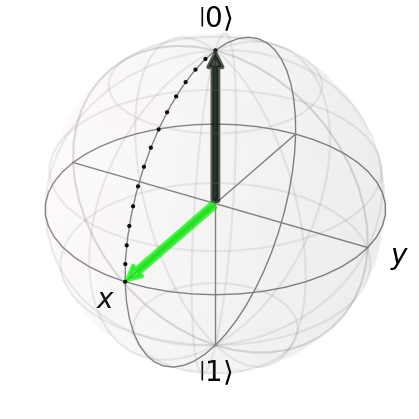

In [26]:
import numpy as np
from qiskit.visualization.bloch import Bloch
from qiskit.visualization.state_visualization import _bloch_multivector_data
 
 
def plot_Nstates(states, axis, plot_trace_points=True):
    """This function plots N states to 1 Bloch sphere"""
    bloch_vecs = [_bloch_multivector_data(s)[0] for s in states]
 
    if axis is None:
        bloch_plot = Bloch()
    else:
        bloch_plot = Bloch(axes=axis)
 
    bloch_plot.add_vectors(bloch_vecs)
 
    if len(states) > 1:
 
        def rgba_map(x, num):
            g = (0.95 - 0.05) / (num - 1)
            i = 0.95 - g * num
            y = g * x + i
            return (0.0, y, 0.0, 0.7)
 
        num = len(states)
        bloch_plot.vector_color = [rgba_map(x, num) for x in range(1, num + 1)]
 
    bloch_plot.vector_width = 3
    bloch_plot.vector_style = "simple"
 
    if plot_trace_points:
 
        def trace_points(bloch_vec1, bloch_vec2):
            # bloch_vec = (x,y,z)
            n_points = 15
            thetas = np.arccos([bloch_vec1[2], bloch_vec2[2]])
            phis = np.arctan2(
                [bloch_vec1[1], bloch_vec2[1]], [bloch_vec1[0], bloch_vec2[0]]
            )
            if phis[1] < 0:
                phis[1] = phis[1] + 2 * pi
            angles0 = np.linspace(phis[0], phis[1], n_points)
            angles1 = np.linspace(thetas[0], thetas[1], n_points)
 
            xp = np.cos(angles0) * np.sin(angles1)
            yp = np.sin(angles0) * np.sin(angles1)
            zp = np.cos(angles1)
            pnts = [xp, yp, zp]
            bloch_plot.add_points(pnts)
            bloch_plot.point_color = "k"
            bloch_plot.point_size = [4] * len(bloch_plot.points)
            bloch_plot.point_marker = ["o"]
 
        for i in range(len(bloch_vecs) - 1):
            trace_points(bloch_vecs[i], bloch_vecs[i + 1])
 
    bloch_plot.sphere_alpha = 0.05
    bloch_plot.frame_alpha = 0.15
    bloch_plot.figsize = [4, 4]
 
    bloch_plot.render()
 
 
plot_Nstates(states, axis=None, plot_trace_points=True)

**Check your understanding** 

Encode the data vector x
 =(0,π/4,π/2) using angle encoding, as described above.

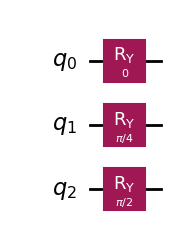

In [29]:

from math import pi
 
qc = QuantumCircuit(3)
state1 = Statevector.from_instruction(qc)
qc.ry(0,0)
qc.ry(pi / 4,1) 
qc.ry(pi/ 2,2)
qc.draw(output="mpl")

### 3.6 Phase Encoding

#### Overview
Phase encoding is similar to angle encoding but uses phase rotations ($R_Z$) instead of axis rotations. Data is encoded in the relative phase between $|0\rangle$ and $|1\rangle$ states.

#### Mathematical Foundation

For a single qubit, phase encoding applies a phase gate $P(\phi)$ after preparing the $|+\rangle$ state with a Hadamard:

$$|x_k^{(j)}\rangle = P(\phi = x_k^{(j)}) H|0\rangle = P(\phi = x_k^{(j)}) |+\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{i x_k^{(j)}} |1\rangle\right)$$

The phase gate is defined as:
$$P(\phi) = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\phi} \end{bmatrix} = e^{i\phi/2} R_Z(\phi)$$

#### Key Characteristics

- **Initialization Required**: Qubits start in $|0\rangle$ (eigenstate of phase), so a Hadamard gate creates the superposition $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
- **Encoding**: Phase gate $P(\phi)$ imparts a relative phase $e^{i\phi}$ to the $|1\rangle$ component
- **Data Mapping**: Each feature $x_k^{(j)}$ becomes a phase angle $\phi = x_k^{(j)}$
- **Range**: $\phi \in (0, 2\pi]$ (rescale data to this range)

#### Multi-Qubit Encoding

For $n$ qubits encoding $N=n$ features, the state is a product state:

$$|\vec{x}^{(j)}\rangle = \bigotimes_{k=1}^{N} P_k(\phi = x_k^{(j)}) |+\rangle^{\otimes N} = \frac{1}{\sqrt{2^N}} \bigotimes_{k=1}^{N} \left(|0\rangle + e^{i x_k^{(j)}} |1\rangle\right)$$

#### Circuit Depth

Phase encoding has a constant depth of **2 layers**:
1. Hadamard layer (prepare $|+\rangle$ states)
2. Phase gate layer (encode data)

This shallow depth makes it ideal for NISQ devices.


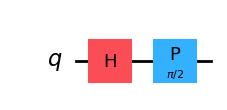

In [31]:
qc = QuantumCircuit(1)
qc.h(0)  
state1 = Statevector.from_instruction(qc)
 
qc.p(pi / 2, 0)  
state2 = Statevector.from_instruction(qc)
 
states = state1, state2
 
qc.draw("mpl", scale=1)

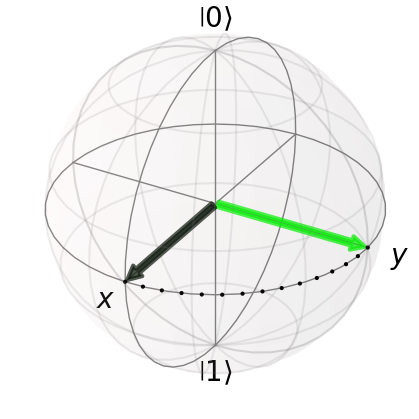

In [32]:
plot_Nstates(states, axis=None, plot_trace_points=True)


Write the code vector x
 = (4,8,5,9,8,6,2,9,2,5,7,0) using phase encoding.

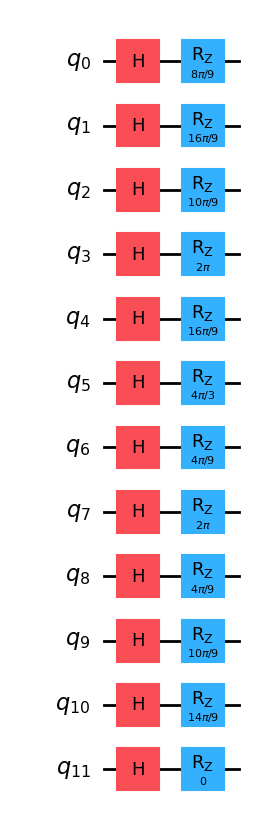

In [35]:
import math
from qiskit import QuantumCircuit

vector_data = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0]

qc = QuantumCircuit(len(vector_data))


for i in range(len(vector_data)):
    qc.h(i)  # Prepara |+⟩
    qc.rz(vector_data[i] * 2 * math.pi / float(max(vector_data)), i)  # Codifica dato normalizado


qc.draw(output="mpl")

### 3.6 Dense Angle Encoding (DAE)

#### Overview
Dense Angle Encoding combines **angle encoding** (RY rotations) and **phase encoding** (RZ rotations) to encode **two features per qubit**, reducing qubit requirements by 50%.

#### Mathematical Foundation

For a single qubit encoding features $x_k^{(j)}$ and $x_\ell^{(j)}$:

$$|x_k^{(j)}, x_\ell^{(j)}\rangle = R_Z(\phi = x_\ell^{(j)}) R_Y(\theta = x_k^{(j)}) |0\rangle$$

This expands to:

$$|x_k^{(j)}, x_\ell^{(j)}\rangle = \cos\left(\frac{x_k^{(j)}}{2}\right)|0\rangle + e^{i x_\ell^{(j)}} \sin\left(\frac{x_k^{(j)}}{2}\right)|1\rangle$$

Where:
- **First feature** ($x_k^{(j)}$): Controls amplitude via $R_Y$ (like angle encoding)
- **Second feature** ($x_\ell^{(j)}$): Controls phase via $R_Z$ (like phase encoding)

#### Multi-Qubit Encoding

For a data vector $\vec{x} = (x_1, x_2, ..., x_N)$ with $N$ even, encoding uses $N/2$ qubits:

$$|\vec{x}\rangle = \bigotimes_{k=1}^{N/2} \left[ \cos(x_{2k-1})|0\rangle + e^{i x_{2k}} \sin(x_{2k-1})|1\rangle \right]$$

Each qubit $k$ encodes:
- **Odd-indexed feature** $x_{2k-1}$ → amplitude (RY rotation)
- **Even-indexed feature** $x_{2k}$ → phase (RZ rotation)

#### Key Characteristics

| Aspect | Description |
|--------|-------------|
| **Qubit efficiency** | 2× reduction (N features need N/2 qubits) |
| **Circuit depth** | Constant (2 gates per qubit) |
| **State type** | Complex-valued (due to phase) |
| **Information per qubit** | 2 classical features |




As an example of DAE, the code below encodes and visualizes the encoding of the features $x_1 = \theta = 3\pi/8$ and $x_2 = \phi = 7\pi/4$.

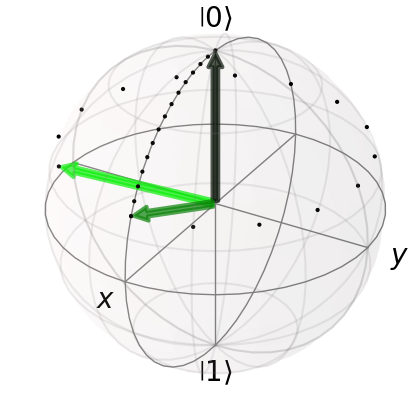

In [36]:
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)
state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)
state3 = Statevector.from_instruction(qc)
states = state1, state2, state3
 
plot_Nstates(states, axis=None, plot_trace_points=True)

**Check your understanding**

Write code to load the vector 
x = (4,8,5,9,8,6,2,9,2,5,7,0,3,7,5) using dense angle encoding.

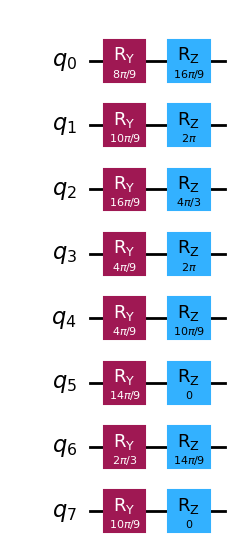

In [38]:
dense_data = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0, 3, 7, 5, 0]
qc = QuantumCircuit(int(len(dense_data) / 2))
entry = 0
for i in range(0, int(len(dense_data) / 2)):
    qc.ry(dense_data[entry] * 2 * math.pi / float(max(dense_data)), i)
    entry = entry + 1
    qc.rz(dense_data[entry] * 2 * math.pi / float(max(dense_data)), i)
    entry = entry + 1
qc.draw(output="mpl")

#### Encoding with built-in feature maps


##### 1. Product States vs. Entangled States
Quantum Machine Learning (QML) uses different strategies to map classical data ($x$) into a quantum state ($|\psi\rangle$).

| Feature | **Product State Encoding** (Angle, Phase, Dense) | **Entangled State Encoding** (Basis, Amplitude) |
| :--- | :--- | :--- |
| **Mapping** | **1:1 or 2:1** (Feature per Qubit). | **Many:1** (Features per State). |
| **Circuit Depth** | **Low (Shallow):** Faster, less noise. | **High (Deep):** Complex due to entanglement. |
| **Capacity** | Low: Requires more qubits. | High: Can store up to $2^n$ features in $n$ qubits. |
| **Correspondence** | Feature $\leftrightarrow$ Qubit. | Feature $\leftrightarrow$ State (e.g., amplitude of $|01\rangle$). |


##### 2. Key Concepts in Qiskit Encoding

#### Data Re-uploading
Encoding does not have to happen only at the beginning of the circuit. 
* Many schemes allow encoding **before and after** entanglement layers.
* This "re-uploading" of data helps the model learn complex boundaries even with a small number of qubits.

#### Encoding at Arbitrary Points
Modern feature maps in Qiskit allow injecting data at different stages of the circuit.
* **N Features** are typically encoded as rotations on **n parameterized gates**.
* **Constraint:** $n \leq N$.

---

##### 3. The Hardware Trade-off
When designing a QML model, maximizing data density (qubits) is **not** the only goal. 
> **Important:** Circuit depth (the number of sequential operations) is often more critical than qubit count. If a circuit is too deep, decoherence and noise will destroy the data before the computation finishes.

####  EfficientSU2: Hardware-Efficient Entanglement

The `EfficientSU2` circuit is a prime example of a **Heuristic Ansatz** used for data encoding and variational algorithms. Its main strength is its ability to encode a high number of features ($N$) onto a small number of qubits ($n$) by using multiple "layers".

#####  How can 2 qubits store 8 features?
As the text mentions, `EfficientSU2` can encode 8 features on only 2 qubits. This is possible because:
1. **Repetition (Layers):** The circuit repeats a pattern of single-qubit rotations ($RY, RZ$) and entanglement gates ($CNOT$).
2. **Parameters as Data:** Each rotation gate ($SU(2)$ gates) can take a different data feature as its angle. 
3. **Data Re-uploading:** By applying rotations, then entangling, and then *more* rotations with *new* data features, the circuit maps the information into a high-dimensional Hilbert space.



#### 🏗️ Structure of EfficientSU2
The circuit consists of two main components:
* **Linear Rotations:** Each qubit undergoes $RY$ and $RZ$ rotations. These are the "SU(2)" gates (Special Unitary group of degree 2).
* **Entanglement Layer:** Usually $CNOT$ gates that link the qubits, creating the "non-local" correlations needed for complex patterns.

#### ⚖️ The Trade-off: Efficiency vs. Depth
While encoding 8 features on 2 qubits is "efficient" in terms of hardware (qubit count), it comes at a cost:
* **Increased Depth:** More features require more layers, making the circuit longer.
* **Barren Plateaus:** In training, very deep `EfficientSU2` circuits can become hard to optimize.
* **Noise:** On real quantum hardware (NISQ), longer circuits are more likely to suffer from decoherence.



#### 🔍 Quick Comparison
| Method | Qubits for 8 features | Circuit Depth |
| :--- | :--- | :--- |
| **Angle Encoding** | 8 Qubits | Very Shallow |
| **EfficientSU2 (Rep=3)** | 2 Qubits | Medium/Deep |

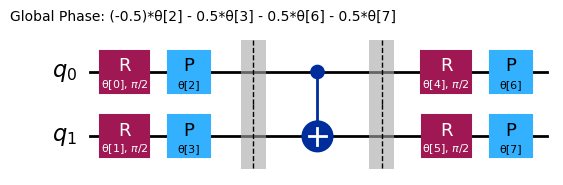

In [40]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circuit.decompose().draw(output="mpl")

##### 🔍 Analysis of the EfficientSU2 Circuit

In the circuit generated above (`num_qubits=2, reps=1`):
* **Rotation Layers:** We observe $RY$ and $RZ$ gates on each qubit. Since there is an initial layer plus one repetition ($reps=1$), we have 2 sets of rotations per qubit.
* **Parameter Count:** Each qubit has 4 rotation gates ($2 \times 2$), totaling **8 parameters** across both qubits.
* **Entanglement:** The qubits are linked via a CNOT gate (entangler), allowing the model to capture correlations between the features.
* **Efficiency:** This demonstrates how we can map 8 classical features into only 2 physical qubits by increasing the circuit depth instead of the qubit count.

#### Why EfficientSU2 Works: The Mathematics of Encoding

##### 1. The 8-Parameter "Magic"
It might seem impossible to store 8 features in 2 qubits because there are only 4 computational basis states ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$). However, each state has a **complex amplitude**:
$$\psi_{final} = (a_0 + ib_0)|00\rangle + (a_1 + ib_1)|01\rangle + (a_2 + ib_2)|10\rangle + (a_3 + ib_3)|11\rangle$$
Since each of the 4 amplitudes has a **real** and an **imaginary** part, we have exactly **8 degrees of freedom** to encode our 8 features.

##### 2. Scaling and Ordering
* **Data Vector:** When encoding a vector like $\vec{x} = (0.1, 0.2, ..., 1.2)$, consistency is key.
* **Qiskit Mapping:** `EfficientSU2` fills the parameters layer by layer, starting from Qubit 0 to Qubit $n$ in the first rotation layer, then moving to the next.
* **Intractability:** As we increase qubits and repetitions, the wave function becomes too complex to write manually, but the quantum computer can still process these high-dimensional states efficiently.



> **Note on Endianness:** The data ordering in `EfficientSU2` is independent of bit-endianness; it simply follows the physical gate structure defined in the circuit layers.

#### 👩‍💻 Implementation: Encoding a 12-Feature Vector

Now that we understand the mathematical capacity of the **EfficientSU2** ansatz, we will proceed to encode a specific data vector $\vec{x}$ into a 3-qubit system. 

##### 🎯 The Goal
We have a data vector with 12 features:
$$\vec{x} = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2)$$

To map these 12 values, we use:
1.  **3 Qubits**: Providing the base states.
2.  **1 Repetition (`reps=1`)**: This creates two "rotation blocks" (initial + one rep).
3.  **4 Rotations per Qubit**: Since each qubit has an $RY$ and $RZ$ gate in each block ($2 \times 2 = 4$), we have a total of $3 \times 4 = 12$ available parameters.

##### ⚙️ How Qiskit Maps the Data
When we bind the vector `x` to the circuit, Qiskit follows a specific sequence:
* It fills the gates **layer by layer**.
* Within each layer, it goes from **top to bottom** (Qubit 0 to Qubit 2).
* First, it assigns the $RY$ gates, then the $RZ$ gates of the first block, and so on.

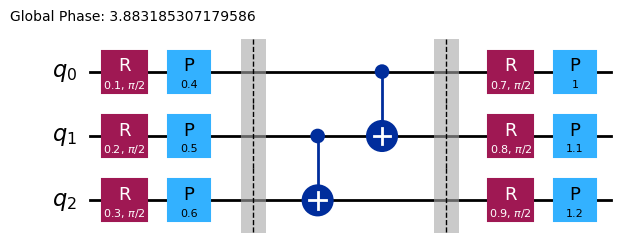

In [41]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.decompose().draw(output="mpl")

#### ⚖️ The Trade-off: Repetitions vs. Circuit Depth

While increasing the number of **repetitions** (`reps`) allows us to store more data on the same number of qubits, it is not a limitless solution.

##### 1. Depth vs. Capacity
* **The Trade-off:** More qubits or more repetitions = **Greater Data Capacity**, but also **Greater Circuit Depth**.
* **The Risk:** In the NISQ (Noisy Intermediate-Scale Quantum) era, deeper circuits lead to more noise and decoherence, which can wash out the encoded information.

##### 2. What is a "Feature Map" anyway?
In Qiskit, encoding **is** a feature mapping. It takes data from its original space (classical) and projects it into a new space: the **Hilbert Space** of the qubits.
* The dimensionality of this Hilbert Space grows as $2^n$ (where $n$ is the number of qubits).
* The relationship between your original data's dimension and this Hilbert Space depends entirely on the circuit architecture chosen.

> **Key Takeaway:** Choosing a feature map is about finding the "Sweet Spot" between having enough expressive power (depth/qubits) and maintaining circuit reliability (low noise).

### Qiskit Pro-Tip: Checking Parameter Capacity

Before assigning your data vector to a circuit like `EfficientSU2`, you need to ensure the number of features matches the number of available "slots" (parameters) in the circuit. Instead of counting gates manually, you can use the built-in property `num_parameters`.

**Run this snippet to check your circuit's capacity:**

```python
# Assuming 'circuit' is your EfficientSU2 instance
print(f"This circuit requires exactly {circuit.num_parameters} features.")

In [42]:
# Assuming 'circuit' is your EfficientSU2 instance
print(f"This circuit requires exactly {circuit.num_parameters} features.")

This circuit requires exactly 12 features.


#### ❓ How is data stored without being lost?
A common doubt is whether adding new layers "overwrites" previous data. In Quantum Computing, this doesn't happen due to:

1. **Constructive Interference:** Each data feature acts as a rotation. Multiple rotations accumulate in the qubit's phase and amplitude, similar to how a compass needle moves based on multiple magnetic forces.
2. **Entanglement:** Entangling layers spread the information across multiple qubits. This ensures that the data isn't just "stacked" on one qubit but distributed across the entire system's state.
3. **Data Re-uploading:** This technique explicitly uses multiple layers to repeat or add information, increasing the "expressive power" of the circuit. The final state is a complex mathematical "signature" of all input features.

#### The Z Feature Map (ZFM)

The **Z Feature Map** is a modular and structured way to encode data, acting as a natural extension of **Phase Encoding**. It maps classical features to quantum phases through a series of Hadamard and Phase gates.

##### ⚙️ Mathematical Structure
The ZFM transforms the ground state $|0\rangle^{\otimes n}$ using a unitary operator $U_{ZFM}$. For a single repetition ($r=1$), the process is:
1.  **Superposition:** Apply a Hadamard layer $H^{\otimes n}$ to create an equal superposition.
2.  **Phase Rotation:** Apply a Phase gate layer $P(x_i)$ where each feature $x_i$ is mapped 1:1 to a qubit.

The full unitary for one repetition is:
$$U_{ZFM} = \left( \bigotimes_{k=1}^N P(x_k) \right) H^{\otimes N}$$

##### 🔑 Key Characteristics
* **1:1 Mapping:** Each data feature corresponds to exactly one qubit.
* **Product State:** Since there is no entanglement (no CNOTs), the qubits remain independent. This makes ZFM **efficient for classical simulation** but limited in capturing correlations.
* **Ordering:** Following Qiskit's convention (little-endian), Feature 0 is mapped to Qubit 0 (the least-significant qubit).

##### 🔄 Repetitions
You can repeat the $(H + P)$ layers $r$ times. Increasing $r$ increases the "depth" of the circuit and allows for more complex interference patterns, though it remains a product state encoding.

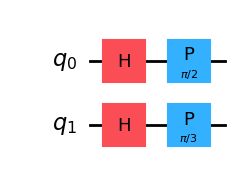

In [43]:
qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)

qc0.h(0)
qc0.p(pi / 2, 0)

qc1.h(0)
qc1.p(pi / 3, 0)

# Combine circuits qc0 and qc1 into 1 circuit
qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)

qc.draw("mpl", scale=1)

##### 🛠️ Manual Implementation of a Z Feature Map
In the code above, we manually constructed a **Z Feature Map** for two features: $x = [\pi/2, \pi/3]$.

* **Hadamard Gates ($H$):** These put both qubits into a superposition state, allowing the phase information to be encoded.
* **Phase Gates ($P$):** These encode the classical data features ($x_0, x_1$) as angular rotations around the Z-axis of the Bloch sphere.
* **Resulting State:** This is a **Product State**. Because there are no entangling gates, the features remain local to their respective qubits.
* **Equivalence:** This manual construction is logically identical to using Qiskit's `ZFeatureMap(feature_dimension=2, reps=1)`.

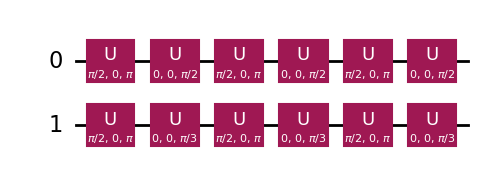

In [45]:
from qiskit.circuit.library import z_feature_map

zfeature_map = z_feature_map(feature_dimension=2, reps=3)
zfeature_map = zfeature_map.assign_parameters([(1 / 2) * pi / 2, (1 / 2) * pi / 3])
zfeature_map.decompose().draw("mpl")

#### Automated Z Feature Map with Repetitions

Using Qiskit's built-in `ZFeatureMap` class allows for quick scaling of the encoding process. In this example, we encode the same vector $\vec{x} = (\pi/2, \pi/3)$ but with **3 repetitions** ($r=3$).

#### 🔑 Key Observations:
* **Parameter Scaling:** Qiskit's `z_feature_map` internally applies a factor of 2 to the angles ($\beta \rightarrow P(2\beta)$). To maintain consistency with our manual encoding, we input $(1/2) \cdot x$.
* **Circuit Depth:** With `reps=3`, the circuit depth increases significantly. Each qubit undergoes a sequence of three Hadamard and Phase gate pairs.
* **Redundancy & Expressivity:** Repeating the same data multiple times through the circuit helps create more complex quantum states, even though the ZFM remains a product state (no entanglement).
* **Decomposition:** Using `.decompose()` is essential to see the actual gates ($H$ and $P$) instead of just the high-level instruction block.


#### The ZZ Feature Map (ZZFM): Introducing Entanglement

The **ZZ Feature Map** is a sophisticated encoding scheme that builds upon the ZFM by adding **two-qubit interactions**. This is a crucial step for Quantum Machine Learning because it introduces correlations between data features.

### The RZZ Gate
The core of this map is the $RZZ(\theta)$ gate. 
* **Function:** It implements a $ZZ$ interaction between two qubits.
* **Entanglement:** It reaches its maximum entangling potential when $\theta = \pi/2$.
* **Complexity:** Unlike the ZFM, the ZZFM creates quantum states that are conjectured to be **classically hard to simulate**, potentially offering a path to quantum advantage.

### Structure & Decomposition
An $RZZ$ gate is not usually a single physical operation; it is decomposed into:
1. A **CNOT** gate.
2. A **Phase rotation ($RZ$)** on the target qubit.
3. Another **CNOT** gate to "close" the interaction.

This sequence ensures that the phase shift depends on the state of *both* qubits simultaneously.

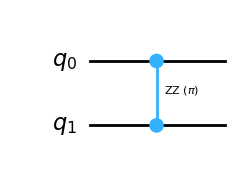

In [46]:
qc = QuantumCircuit(2)
qc.rzz(pi, 0, 1)
qc.draw("mpl", scale=1)

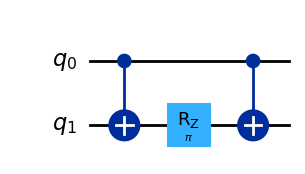

In [47]:
qc.decompose().draw("mpl", scale=1)

####  Deep Dive: Anatomy of the $RZZ$ Gate

When we use the `ZZFeatureMap`, the core interaction is performed by the **$RZZ(\theta)$** gate. Since most quantum hardware doesn't run this gate natively, we must **decompose** it into more fundamental operations.

#### What happens in the decomposition?
As seen in the circuit diagram above:
1. **First CNOT:** It creates entanglement between $q_0$ (control) and $q_1$ (target).
2. **$R_z(\pi)$ Gate:** This is the "Data Slot". The classical feature (in this case, $\pi$) is encoded as a phase rotation. Because of the previous CNOT, this rotation now affects the **joint state** of both qubits rather than just one.
3. **Second CNOT:** It "untangles" the qubits' computational states while preserving the phase shift.


#### Why is this the "Magic" of ZZFeatureMap?
* **Correlations:** Unlike the ZFM where qubits are independent, this structure forces the qubits to "talk" to each other. 
* **Complexity:** This allows the quantum computer to represent relationships between features (e.g., $x_i$ and $x_j$), which is exactly what a classical computer struggles to simulate as the number of qubits grows.

#### The ZZ Feature Map: Non-linear Interactions

The **ZZ Feature Map (ZZFM)** is more than just a data carrier; it is a mathematical engine that encodes relationships between features.

##### 1. Circuit Composition
A single repetition consists of:
* **ZFM Layer:** Hadamard gates ($H^{\otimes N}$) and Phase gates ($P(x_k)$) to encode individual features.
* **ZZ Layer ($U_{ZZ}$):** A layer of $RZZ$ gates that entangles pairs of qubits.

##### 2. The Interaction Function ($\phi$)
When entangling two qubits $p$ and $q$, the rotation angle is determined by a specific non-linear mapping:
$$\theta_{q,p} \rightarrow \phi(x_q, x_p) = 2(\pi - x_q)(\pi - x_p)$$
This function ensures that the quantum state depends on the **interaction** of both features, allowing the model to detect patterns that exist only when certain features are combined.

##### 3. Scaling with Repetitions
Like the ZFM, the ZZFM can be repeated $r$ times. Each repetition adds more depth and complexity to the state:
$$U_{ZZFM}^{(r)}(\vec{x}) = \prod_{s=1}^r [U_{ZZ}(\vec{x}) \left( \bigotimes_{k=1}^N P(x_k) \right) H^{\otimes N}]$$



> **Note:** The ZZFM is particularly valuable in Quantum Machine Learning because it maps classical data into a high-dimensional Hilbert space where linear separation of non-linear data becomes possible.

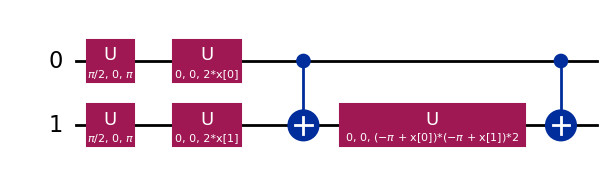

In [48]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose(reps=1).draw("mpl", scale=1)

#### 🧬 Detailed Analysis of the `ZZFeatureMap`
In this implementation with `feature_dimension=2` and `reps=1`, we can observe the full encoding pipeline:

1. **Superposition Layer:** Hadamard gates are applied to all qubits to prepare the quantum state.
2. **Individual Encoding:** Each feature $x_i$ is mapped to its respective qubit using a $Z$ rotation.
3. **Entanglement Layer (`linear`):** The qubits are linked via an $RZZ$ interaction. 
    * **The Mechanism:** This is visualized as a `CNOT-RZ-CNOT` sequence.
    * **The Interaction:** The rotation angle in the entangling gate represents the correlation between $x_0$ and $x_1$ through the non-linear function $\phi(x_0, x_1) = 2(\pi - x_0)(\pi - x_1)$.

##### ⚖️ Key takeaway:
The `ZZFeatureMap` is more "expressive" than the `ZFeatureMap` because it doesn't just treat features as independent variables; it creates a quantum state that mathematically represents how those features interact with each other.

#### Customization and Linear Entanglement in ZZFM

As we scale to higher-dimensional data (e.g., a 4D vector $\vec{x}$), the **ZZ Feature Map** offers flexibility in how features interact.

##### 1. Flexible Mapping ($\phi$)
While the default mapping function is $\phi(x_1, x_2) = 2(\pi - x_1)(\pi - x_2)$, Qiskit allows for **custom preprocessing**. This means you can redefine the relationship between qubit pairs to better suit the specific patterns in your dataset.

##### 2. Linear Entanglement Topology
With `entanglement="linear"`, the circuit connects qubits in a sequential chain ($q_i$ interacts with $q_{i+1}$). 
* **Structure:** For 4 qubits, you will see three $RZZ$ interaction blocks: $(q_0, q_1)$, $(q_1, q_2)$, and $(q_2, q_3)$.
* **Purpose:** This reduces circuit depth and complexity compared to "full" entanglement, focusing only on local correlations between adjacent features.

##### 3. Scaling to 4 Qubits
In a 4-qubit ZZFM with `reps=1`, the circuit will perform:
1. Four Hadamard gates ($H^{\otimes 4}$).
2. Four individual Phase rotations ($P(x_1)$ to $P(x_4)$).
3. The linear sequence of $RZZ$ "sandwich" gates using the $\phi$ function for each pair.

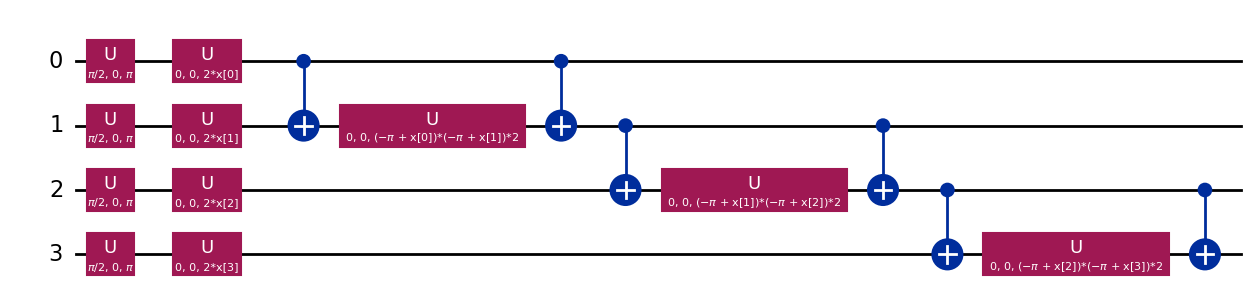

In [49]:
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose().draw("mpl", scale=1)

#### 📶 Analyzing the 4-Qubit Linear ZZ Feature Map

This circuit expands the feature space to 4 dimensions using a **linear entanglement** strategy. Here is the breakdown:

1. **Global Superposition:** All 4 qubits start with a Hadamard layer to enable phase interference.
2. **Individual Encoding:** Features $x_1$ through $x_4$ are encoded via $R_z$ rotations on their respective qubits ($q_0$ to $q_3$).
3. **Linear Entanglement Chain:** The circuit creates a sequence of three $R_{ZZ}$ interactions:
   * Interaction between $(q_0, q_1)$
   * Interaction between $(q_1, q_2)$
   * Interaction between $(q_2, q_3)$
4. **Feature Correlation:** Each interaction uses the non-linear mapping $\phi(x_i, x_j) = 2(\pi - x_i)(\pi - x_j)$. This specific setup allows the quantum state to "learn" correlations between **neighboring** features in the data vector.

**Key Characteristic:** By using "linear" instead of "full" entanglement, we save on circuit depth and reduce the number of CNOT gates, making it more suitable for current noisy quantum hardware (NISQ).

#### The Pauli Feature Map (PFM): The General Framework

The **Pauli Feature Map** is the universal generalization of both ZFM and ZZFM. It allows for the use of any Pauli operators ($I, X, Y, Z$) to define how data is encoded and how qubits interact.

##### 1. Mathematical Foundation
The PFM is represented by a unitary operator that mimics physical time evolution:
$$U(\vec{x}) = \exp\left(i \sum_{S \in \mathcal{I}} \phi_S(\vec{x}) \prod_{i \in S} \sigma_i\right)$$
* **$\sigma_i$:** Pauli operators ($X, Y, Z$) chosen for the encoding.
* **$\phi_S(\vec{x})$:** The mapping function. It uses $x_i$ for single qubits and $\prod (\pi - x_j)$ for entangling interactions.

##### 2. The Ising Model Analogy
The PFM acts like a **propagator** ($\exp(itH)$). Instead of time ($t$), we use our data values to drive the quantum state's evolution. The "entanglement schemes" (linear, circular, etc.) define the "couplings" between spins in this simulated quantum system.

##### 3. Flexibility
By using the `pauli_feature_map` class in Qiskit, we can pass strings like `['Y', 'XX']`. This means:
* **'Y'**: Single-qubit $Y$ rotations based on individual features.
* **'XX'**: Two-qubit interactions using the $XX$ basis (nearest-neighbor entanglement if "linear").

> **Key takeaway:** The PFM is highly expressive. While ZFM and ZZFM are standard defaults, PFM allows researchers to tailor the "quantum DNA" of the circuit to specific types of data.

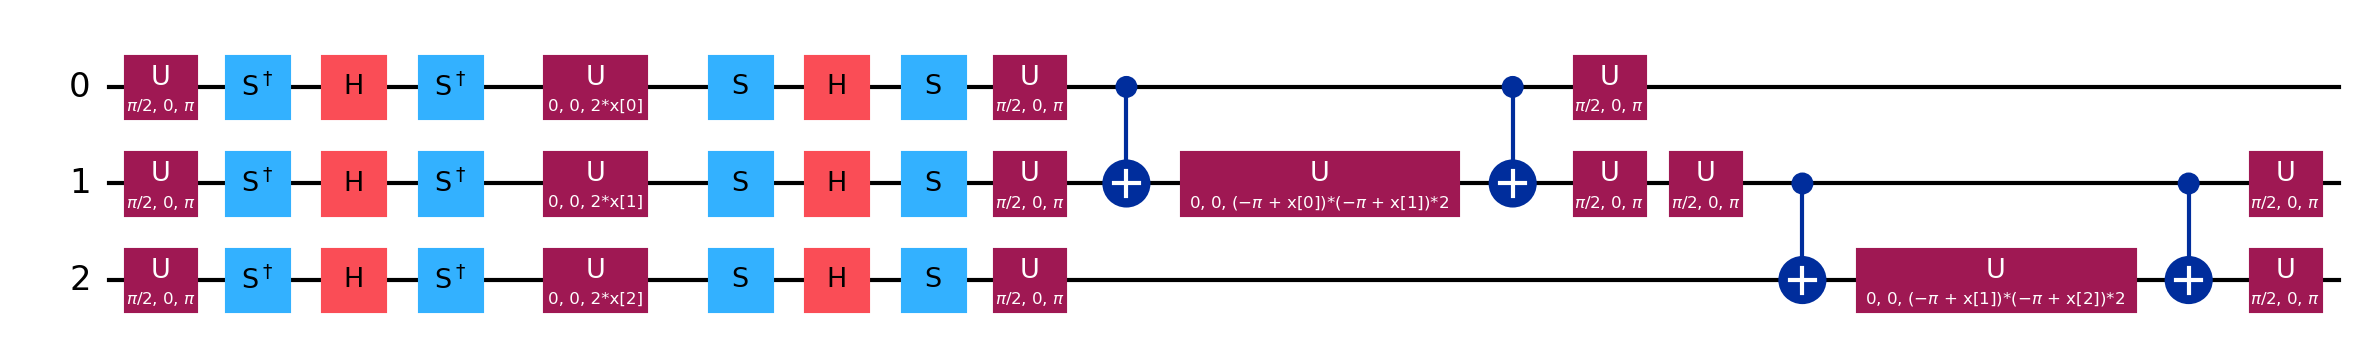

In [50]:
from qiskit.circuit.library import pauli_feature_map

feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)

pfmap.decompose().draw("mpl", scale=1.5)

##### Analyzing the Pauli Feature Map (`paulis=["Y", "XX"]`)

The **Pauli Feature Map** is the most flexible encoding method, as it allows for rotations in different axes of the Bloch sphere.

#### 1. Components of this specific circuit:
* **Single-qubit Gates ('Y'):** Data features are encoded using $RY(\theta)$ rotations. This modifies the probability amplitudes directly.
* **Two-qubit Gates ('XX'):** The entanglement is based on the $XX$ interaction. To achieve this on a standard quantum computer, Qiskit wraps the interaction in Hadamard gates to perform a change of basis.
* **Linear Topology:** With 3 qubits, the interactions follow a chain pattern: $(q_0 \leftrightarrow q_1)$ and $(q_1 \leftrightarrow q_2)$.

#### 2. The Physical Analogy:
This circuit simulates a **Quantum Ising Model**. The 'Y' gates represent external fields acting on individual spins, while the 'XX' gates represent the coupling (interaction) between neighboring spins. 

**Key Takeaway:** By choosing different Pauli strings, we can tailor the "geometry" of our feature map to better fit the structure of our classical data, potentially discovering more complex patterns during the learning process.

#### Gallery of Pauli Feature Maps

The `PauliFeatureMap` is the ultimate tool for designing custom quantum embeddings. By selecting different combinations of Pauli operators, we can control how data is mapped onto the Bloch sphere and how features interact.

##### Common Configurations for 2-Qubit Circuits:

1. **Standard ZZ (`paulis=['Z', 'ZZ']`):** * Maps features to the phase of the qubits. 
   * The entanglement represents correlations in the computational basis ($|0\rangle, |1\rangle$).

2. **Transverse Interaction (`paulis=['Z', 'XX']`):**
   * Combines phase encoding with $XX$ entanglement. 
   * Visually, you will see Hadamard gates wrapping the $RZZ$ "sandwich" to perform a basis change.

3. **Multi-Axis Encoding (`paulis=['X', 'Y']`):**
   * A single feature can be encoded multiple times across different axes ($X$ and $Y$).
   * This increases the "expressive power" of the circuit, allowing it to represent more complex boundaries between data classes.

##### Circuit Depth vs. Expressivity
Each additional Pauli string increases the **depth** of the circuit. While a map like `['Z', 'X', 'ZZ', 'XX']` is highly expressive and can capture intricate patterns, it is also more susceptible to noise on real quantum hardware due to the high number of gates.

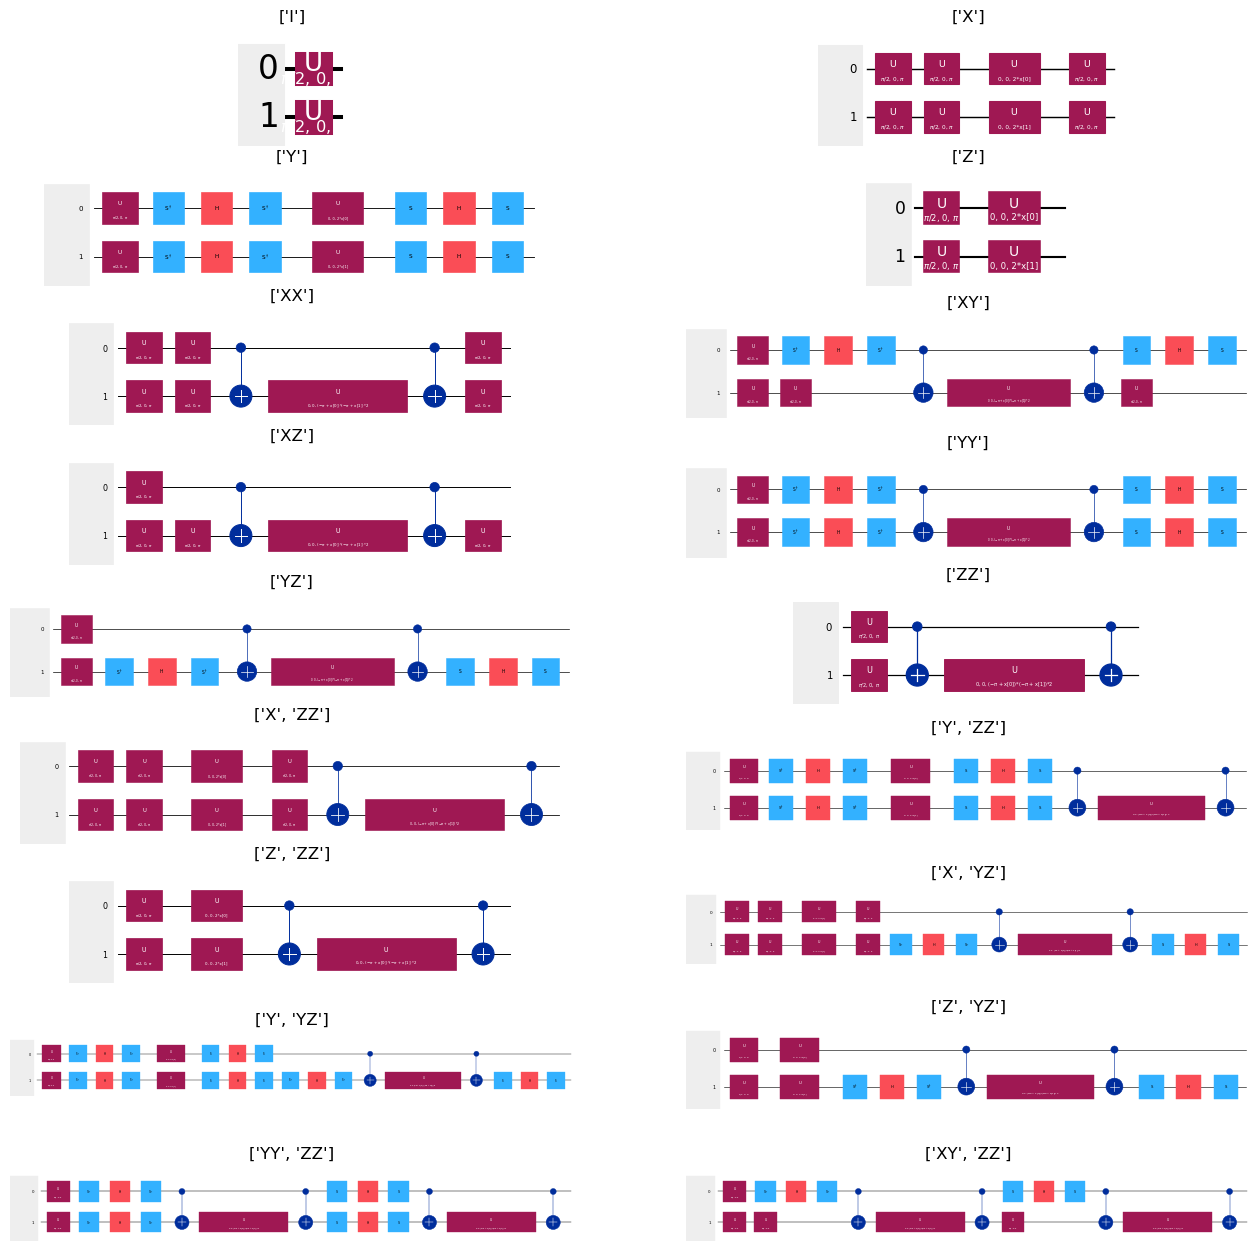

In [52]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

feature_dim = 2
fig, axs = plt.subplots(9, 2)
i_plot = 0
for paulis in [
    ["I"],
    ["X"],
    ["Y"],
    ["Z"],
    ["XX"],
    ["XY"],
    ["XZ"],
    ["YY"],
    ["YZ"],
    ["ZZ"],
    ["X", "ZZ"],
    ["Y", "ZZ"],
    ["Z", "ZZ"],
    ["X", "YZ"],
    ["Y", "YZ"],
    ["Z", "YZ"],
    ["YY", "ZZ"],
    ["XY", "ZZ"],
]:
    pfmap = pauli_feature_map(feature_dimension=feature_dim, paulis=paulis, reps=1)
    circuit_drawer(
        pfmap.decompose(),
        output="mpl",
        style={"backgroundcolor": "#EEEEEE"},
        ax=axs[int((i_plot - i_plot % 2) / 2), i_plot % 2],
    )
    axs[int((i_plot - i_plot % 2) / 2), i_plot % 2].title.set_text(paulis)
    i_plot += 1

fig.set_figheight(16)
fig.set_figwidth(16)

#### 🖼️ Comparative Analysis: Pauli Feature Map Gallery

This extensive visualization demonstrates the flexibility of the `PauliFeatureMap` class. By iterating through different Pauli strings, we observe how the circuit architecture adapts to different encoding strategies.

##### 🧩 Key Categories:

1. **Uncorrelated Maps (`['X']`, `['Y']`, `['Z']`):**
   * These create independent rotations for each feature.
   * **Result:** A "Product State" where features do not interact. Low circuit depth.

2. **Basis Transformation (`['XX']`, `['YY']`):**
   * Since quantum hardware typically operates in the Z-basis, maps using X or Y interactions require **basis-change gates** (like Hadamard or S gates) surrounding the entangling CNOTs.
   * **Result:** Increased circuit depth but unique geometric perspectives on the data.

3. **Hybrid Maps (e.g., `['X', 'ZZ']`):**
   * These combine single-qubit rotations with multi-qubit entanglement.
   * **Result:** High expressivity. The same data feature $x_i$ is "re-uploaded" into the circuit in different ways, creating complex non-linear boundaries.

##### ⚖️ The Trade-off
As seen in the grid, moving from `['Z']` to `['XY', 'ZZ']` drastically increases the number of gates. In the NISQ era, while a more complex map can theoretically "understand" the data better, the **accumulated noise** from extra CNOTs might degrade the final performance.

#### 🛠️ From Theory to Reality: Hardware-Efficient Feature Mapping

A Feature Map may be mathematically superior, but in the **NISQ** (Noisy Intermediate-Scale Quantum) era, success depends on **Hardware Efficiency**.

##### 1. The Transpilation Process
Our abstract circuits (using gates like `H`, `RZZ`, or `YY`) do not run directly on quantum hardware. They must undergo **Transpilation**:
* **Native Gates:** Quantum processors only "understand" a limited set of basis gates (e.g., `ibm_torino` uses `{CZ, ID, RZ, SX, X}`). 
* **Decomposition:** A single logical gate in our code is broken down into multiple physical gates, significantly increasing the **Circuit Depth**.
* **Connectivity & SWAPs:** If our map entangles two qubits that are not physically connected on the chip, the transpiler must add **SWAP gates**, which are slow and error-prone.



##### 2. Strategies for Optimization (Havlicek et al. 2019)
To minimize noise and **decoherence** (the loss of quantum information), we apply the following hardware-efficient strategies:

* **Depth Minimization:** Reducing the number of time-aligned gate steps gives noise less time to corrupt the computation.
* **Topological Matching:** Choosing a `linear` entanglement scheme instead of `full` prevents the overhead of unnecessary SWAP gates.
* **Qubit Selection:** Not all physical qubits are equal. Experts target subcircuits with the highest **T1 relaxation times** (longer qubit life) and the lowest **CZ/CNOT error rates**.
* **Second-Order Expansions:** The `ZZFeatureMap` is ideal because it relies on 2-qubit interactions, which map directly to the native capabilities of current superconducting processors.



##### 3. Technical Summary: Expressivity vs. Noise

| Feature | Impact on Hardware | Recommended Strategy |
| :--- | :--- | :--- |
| **Repetitions (`reps`)** | Linearly increases noise exposure. | Keep to the minimum required for accuracy. |
| **`full` Entanglement** | Causes a massive spike in CNOT count. | Prefer `linear` or `circular` topologies. |
| **N-qubit Interactions** | Requires complex, deep decompositions. | Stick to 2-qubit interactions (2nd order). |

> **Expert Insight:** The "Quantum Advantage" is found at the intersection of a circuit complex enough to outperform classical computers, but efficient enough to survive the noise of a real quantum processor.

### 🧬 Introduction to Quantum Kernels

The **Quantum Kernel Method** refers to any approach that uses quantum computers to estimate a kernel, which can be the entire kernel matrix or its individual entries.

##### 1. Definition and Goal
* **Feature Mapping ($\Phi$):** It is a mapping from a vector $\vec{x} \in \mathbb{R}^d$ to a higher-dimensional space $\mathbb{R}^{d'}$.
* **Objective:** The goal is to make data categories separable by a **hyperplane**.
* **Kernel Function ($K$):** It takes vectors from the feature-mapped space and returns their inner product:
$$K(x,y) = \langle \Phi(x) | \Phi(y) \rangle$$



##### 2. Quantum Estimation
In this method, the feature mapping is executed by a **quantum circuit**. The kernel is estimated through:
* Measurements performed on the circuit.
* Relative measurement probabilities.

##### 3. Pre-coded vs. Custom Circuits
A key part of the process is comparing different types of encoding circuits:
* **Pre-coded circuits:** These often use substantial entanglement but can result in high **circuit depths**.
* **Hand-coded circuits:** Custom-built by the user. While they allow for depth control, they may sometimes provide insufficient entanglement to be useful.



##### 4. Workflow
Before performing a detailed kernel matrix estimation, the process follows the **Qiskit patterns** workflow to outline how the estimation will be managed and executed.

### Step 1: Map classical inputs to a quantum problem

**Input:** Training dataset  
**Output:** Abstract circuit for calculating a kernel matrix entry

The initial stage of the process is to encode classical data into a quantum circuit, effectively mapping it into the **Hilbert space** of the quantum computer.

#### 1. Constructing Data-Dependent Circuits
To encode the data, we build a specific quantum circuit. There are two primary approaches discussed:
* **Custom Circuits:** Constructing a manual circuit tailored to the specific data.
* **Pre-made Feature Maps:** Using built-in options such as the `zz_feature_map`.

#### 2. Estimating the Inner Product
The core of the quantum kernel workflow is the estimation of a single kernel matrix element. This requires:
* Encoding **two different data points** simultaneously.
* Mapping both data vectors into the feature space to estimate their **inner product**.



#### 3. Iteration and Integration
While the full workflow involves calculating many such inner products between mapped vectors and integrating them with classical machine learning methods, the fundamental unit of the process is the estimation of these individual kernel matrix elements using the data-dependent circuits.

###  Simplified Logic: How do we calculate similarity?

If the math feels complex, think of it as a **"Quantum Lock and Key"** mechanism.

#### 1. The "Mapping" (Preparing the states)
We have two data points, $x_i$ and $x_j$. Each one has its own quantum "signature":
* Circuit $\Phi(x_i)$ creates the state for data point **A**.
* Circuit $\Phi(x_j)$ creates the state for data point **B**.

#### 2. The Similarity Test (The "Dagger" $\dagger$ Trick)
To know how similar **A** and **B** are, we run them back-to-back in a single circuit, but with a twist:
1.  We start at "Home" (the $|0\rangle$ state).
2.  We use the first circuit to move to state **A**.
3.  We use the **Inverse** (Dagger $\dagger$) of the second circuit to try to "undo" the path using data **B**.



#### 3. Why the All-Zero State ($|0\rangle$)?
* **If A and B are identical:** The second circuit (the inverse) will perfectly undo what the first one did. You will end up exactly where you started: at **"Home" ($|0\rangle$)**.
* **If A and B are totally different:** The second circuit will lead you somewhere else in the quantum space. When you measure, you won't find the qubits in the $|0\rangle$ state.

#### 4. The Result
The probability of measuring the **All-Zero State ($P_0$)** is our "Similarity Score":
* **$P_0 = 1$ (100%):** The points are identical.
* **$P_0 = 0$ (0%):** The points are completely different.

> **In short:** We aren't measuring the data itself; we are measuring **how well the second circuit "undoes" the first one**. That probability is our Kernel value.

### Step 2: Optimize problem for quantum execution

**Input:** Abstract circuit (not hardware-specific)  
**Output:** Target circuit optimized for a specific QPU

Once the abstract circuit is defined, it must be adapted to the physical constraints of a real quantum computer.

#### 1. Hardware Optimization (Pass Manager)
Using Qiskit's `generate_preset_pass_manager` with `optimization_level=3`, we apply the highest level of refinement. This "optimization" is focused on **hardware performance**, not the ML model's accuracy. It involves:
* **Qubit Selection:** Choosing physical qubits with the lowest error rates.
* **Depth Minimization:** Mapping the circuit to reduce the number of gate steps.
* **Layout Mapping:** Matching the abstract circuit to the actual physical connections (topology) of the QPU.

#### 2. Iterative Nature
Since each entry in a kernel matrix involves a different pair of data points, each pair generates a unique circuit. Therefore, this optimization step must be repeated for every unique circuit created in the matrix.



### Step 3: Execute using Qiskit Runtime Primitives

**Input:** Target circuit  
**Output:** Probability distribution

#### 1. The Sampler Primitive
We use the **Sampler** primitive to execute the circuit and reconstruct the probability distribution of the resulting states. 

#### 2. Quasi-Probabilities
The output is often called a **"quasi-probability distribution"**. This happens because:
* **Noise Mitigation:** When error mitigation techniques are applied, the resulting values might not sum exactly to 1.
* **Hardware Noise:** Real-world interference affects the precision of the samples.

For the Quantum Kernel method, our primary focus is extracting the specific probability (or quasi-probability) of the **all-zero state ($|0\rangle^{\otimes N}$)** from this distribution.

# If you have not already, install scikit learn
!pip install scikit-learn

### Single kernel matrix entry

#### Step 1: Map classical inputs to a quantum problem
Let us first consider a data set with just a few features.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Two mock data points, including category labels, as in training
small_data = [
    [-0.194, 0.114, -0.006, 0.301, -0.359, -0.088, -0.156, 0.342, -0.016, 0.143, 1],
    [-0.1, 0.002, 0.244, 0.127, -0.064, -0.086, 0.072, 0.043, -0.053, 0.02, -1],
]

# Data points with labels removed, for inner product
train_data = [small_data[0][:-1], small_data[1][:-1]]

In [ ]:
Using the z_feature_map:

In [61]:
# from qiskit.circuit.library import zz_feature_map
# fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)

from qiskit.circuit.library import z_feature_map

fm = z_feature_map(feature_dimension=np.shape(train_data)[1])


unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

circuit depth =  9


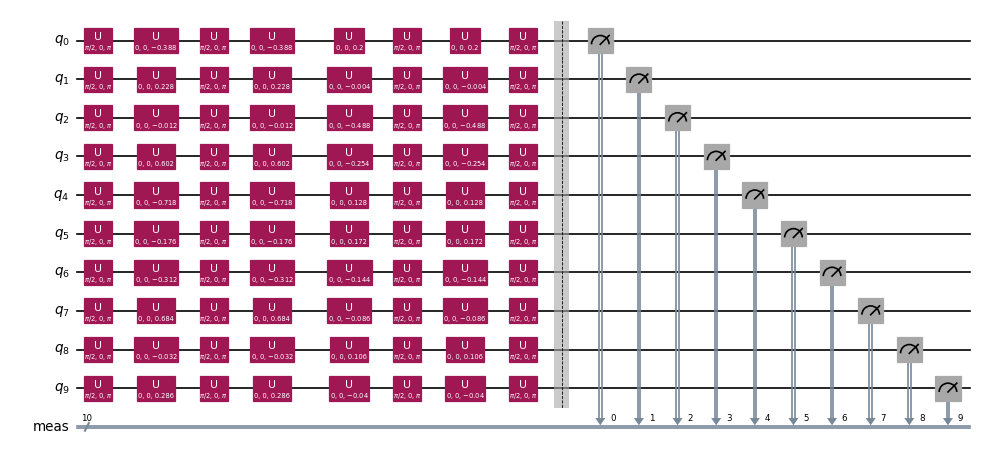

In [62]:
from qiskit.circuit.library import unitary_overlap


overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

### Step 2: Optimize problem for quantum execution

We start by selecting the least busy backend, then optimize our circuit for running on that backend.

In [69]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Usa el token que generaste en la página de IBM
TU_TOKEN = "ZbMqhnH07boYTEwf_rMLqjoMDI-FpZFEuUstWl-Axj68" 

# Cambiamos el canal al nombre exacto que espera: 'ibm_quantum_platform'
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token=TU_TOKEN, 
    overwrite=True
)

print("✅ ¡Cuenta vinculada correctamente con el canal oficial!")

✅ ¡Cuenta vinculada correctamente con el canal oficial!


In [75]:
from qiskit_ibm_runtime import QiskitRuntimeService

# 1. Cargamos el servicio (Qiskit buscará tus credenciales guardadas)
try:
    service = QiskitRuntimeService(channel="ibm_quantum_platform")
    
    # 2. Verificamos qué vio Qiskit
    instancias = service.instances()
    print(f"✅ ¡Conectado! Instancias encontradas: {instancias}")
    
    # 3. Seleccionamos el backend real
    # min_num_qubits debe ser igual o mayor a los que usa tu Feature Map (fm)
    backend = service.least_busy(operational=True, simulator=False)
    print(f"🚀 Trabajando con el procesador real: {backend.name}")

except Exception as e:
    print(f"❌ Error al conectar: {e}")
    print("Tip: Si el error persiste, reinicia el Kernel de Jupyter y vuelve a correr esta celda.")

qiskit_runtime_service.__init__:WARNING:2026-03-17 17:39:11,618: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


✅ ¡Conectado! Instancias encontradas: [{'crn': 'crn:v1:bluemix:public:quantum-computing:us-east:a/70e34c6be95246d698a8153271986a03:c48a6d34-fcca-45b8-b3a0-587b8c861d59::', 'plan': 'open', 'name': 'open-instance', 'tags': [], 'pricing_type': 'free'}]


qiskit_runtime_service.backends:WARNING:2026-03-17 17:39:12,255: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-17 17:39:14,959: Using instance: open-instance, plan: open


🚀 Trabajando con el procesador real: ibm_fez


In [76]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-17 17:39:28,705: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-17 17:39:29,677: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-17 17:39:33,126: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [78]:
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

In [79]:
print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

#### Step 3: Execute using Qiskit Runtime Primitives

In this stage, we transition from local circuit definition to remote execution using **Qiskit Runtime Primitives**. These high-level interfaces are designed to optimize the communication between our local environment and IBM's quantum systems.

##### Key Considerations:
* **Scalability:** While simulators are excellent for debugging and "scaled-down" versions of our data, they are not feasible for utility-scale calculations. 
* **Efficiency:** Using Primitives allows us to leverage error suppression and mitigation techniques directly on the quantum hardware.
* **Strategy:** For this project, we prioritize executing on a **real backend** to capture actual quantum noise, reserving simulation only for code verification.

---

> **Technical Note:** The syntax for running on a simulator is provided in the comments below. For this dataset, with a small number of features, running on a simulator remains an option for rapid prototyping. However, for utility-scale calculations, simulation is typically not feasible, and physical backends must be used to ensure valid results.

In [80]:
# Run this for a simulator
# from qiskit.primitives import StatevectorSampler

# from qiskit_ibm_runtime import Options, Session, Sampler

# num_shots = 10000

# Evaluate the problem using state vector-based primitives from Qiskit
# sampler = StatevectorSampler()
# results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
# counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
# counts = results[0].data.meas.get_int_counts()

In [82]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.

# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 10000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

## Step 4: Post-process, return result in classical format

Once the quantum execution is complete, we must translate the raw measurement counts back into a classical value that our Machine Learning model can understand. 

### Key Concept: Zero-State Probability
As described in the introduction, the most useful measurement for a Fidelity Quantum Kernel is the probability of measuring the all-zero state: 
$$|00\dots0\rangle$$

### Why the Zero State?
In a **Compute-uncompute** circuit (like the one used for the overlap), the fidelity between two data points is directly proportional to the probability that the qubits return to their initial ground state after the transformation. 

* **High Probability of $|0\rangle$:** Indicates that the two input feature vectors (e.g., your GaAs gate voltages) are highly similar.
* **Low Probability of $|0\rangle$:** Indicates that the inputs are distinct in the quantum feature space.

---

> **Note:** The final kernel entry is calculated by dividing the number of times the zero state was measured by the total number of shots:
>
> $$\text{Kernel Entry} = \frac{\text{Counts}(|00\dots0\rangle)}{\text{Total Shots}}$$

In [83]:
counts.get(0, 0.0) / num_shots

0.6621

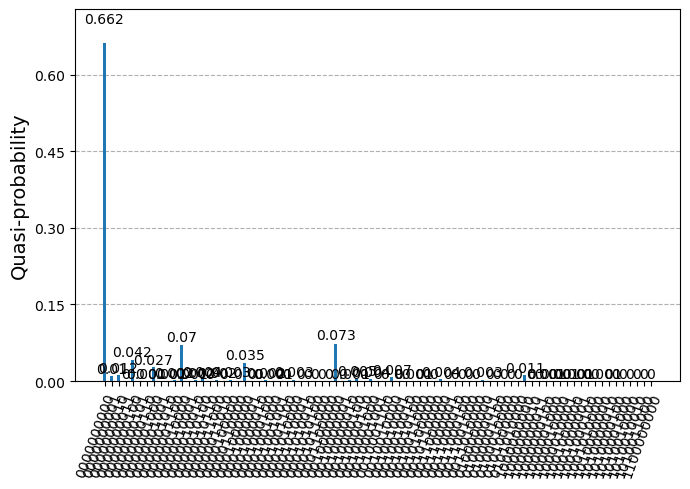

In [84]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)

### Analysis of Results: Quasi-probability Distribution

The histogram above displays the measurement results from the IBM quantum backend. 

* **Primary Result:** The state $|00000\rangle$ shows a quasi-probability of **0.662**.
* **Kernel Entry:** This value represents the **Quantum Fidelity** between the two input vectors. In our case, a fidelity of ~66% indicates a significant overlap between the electronic states of the simulated GaAs device for these specific gate configurations.
* **Interpretation:** The presence of minor peaks in other states is attributed to a combination of physical hardware noise (decoherence/gate errors) and the inherent non-identity of the compared feature vectors.

**Conclusion:** The calculated entry for the Quantum Kernel Matrix at this position is **0.662**.

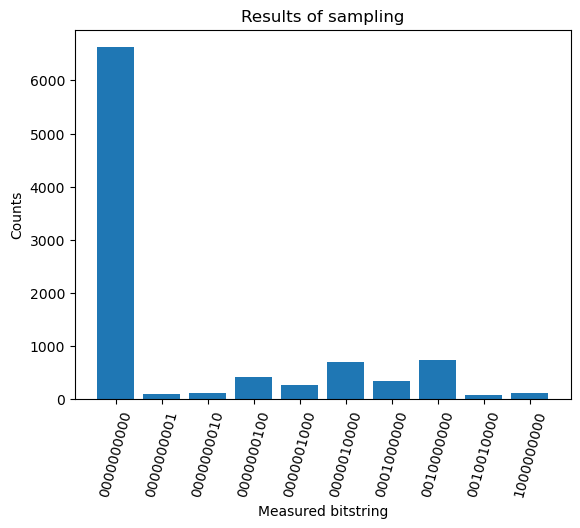

In [85]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)

### Step 5: Visualization of Sampling Results

After retrieving the measurement data from the IBM Quantum backend, we visualize the probability distribution to analyze the performance of our quantum circuit.

### Analysis of the "Results of Sampling" Plot

The histogram illustrates the distribution of measured bitstrings across the qubits. 

* **Dominant State:** The state $|0000000000\rangle$ (represented by the first bar) shows the highest frequency, with over **6,000 counts**.
* **Fidelity Interpretation:** In the context of a compute-uncompute overlap circuit, this high count in the zero-state confirms a strong similarity between the encoded feature vectors.
* **Noise Profile:** The secondary, smaller peaks represent other measured bitstrings. On a real quantum processor, these are expected due to:
    * **Gate Errors:** Imperfections in the execution of quantum operations.
    * **Readout Noise:** Statistical errors during the measurement phase.
    * **Decoherence:** The loss of quantum information during the 4-second execution window.

### Mathematical Output
The visualization focuses on the **Top 10** most frequent states plus the zero-state. By converting these counts into a probability (Counts / Total Shots), we obtain the final entry for our **Quantum Kernel Matrix**.

---

> **Summary:** The clear dominance of the zero-state indicates that the quantum hardware successfully executed the high-dimensional mapping. 

## Step 5.1: Interpreting the Kernel Entry and Circuit Depth

The measurement of a **0.662 fidelity** provides significant insight into both our data and the effectiveness of our quantum workflow.

### 1. Data Similarity vs. Feature Map Effectiveness
A value of 0.662 (out of a maximum of 1.0) indicates a large overlap in the feature space. This suggests two possibilities:
* **Inherent Similarity:** The two data points are naturally similar and will likely be categorized in the same class.
* **Feature Map Performance:** Our current feature map effectively maps similar data to nearby regions in the Hilbert space. 

To confirm this, we must eventually process the **entire dataset** to ensure the resulting kernel matrix effectively separates different classes with high accuracy.

### 2. The Impact of Circuit Depth on Noise
The choice of the `z_feature_map` was strategic. Because it results in a low **transpiled depth** (depth 1), it minimizes noise. 

* **Warning on Complexity:** If the circuit becomes too deep (e.g., switching to a `zz_feature_map` with linear entanglement), the probability of measuring the zero state can drop drastically (e.g., to $0.0015$) due to cumulative hardware errors.
* **Hardware Reality:** On real processors, even a well-matched feature map can yield poor results if the circuit depth exceeds the coherence time of the qubits.

---

> **Conclusion:** For our integration with **QTCAD**, maintaining shallow circuit depths will be vital. High-fidelity results like the one achieved here ($0.662$) are only possible when the feature map complexity is balanced against the physical noise limits of the IBM backend.

### 4. Full Kernel Matrix: Binary Classification

In this section, we extend the binary classification process to a complete dataset. This step is essential for integrating quantum processing with classical statistical analysis.

#### Objectives
* **Classical Post-processing:** Use the quantum-calculated kernel matrix as input for traditional classification algorithms (e.g., Support Vector Machines).
* **Performance Metrics:** Evaluate the model’s effectiveness by calculating accuracy scores for the training and testing phases.

#### Dataset Structure
The analysis utilizes a structured dataset designed for classification tasks:
* **Size:** 128 data points (rows).
* **Features:** 14 dimensions per data point.
* **Labels:** A 15th element indicating the binary category ($\pm 1$).

#### Data Partitioning (Split)
To ensure a robust evaluation of the model, the dataset is divided as follows:
1. **Training Set:** The first 90 data points.
2. **Test Set:** The following 30 data points.

In [88]:
import pandas as pd

# Definimos la URL directa del dataset
data_url = "https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv"

# 1. Leemos el archivo directamente desde la web
df = pd.read_csv(data_url, sep=",", header=None)

# 2. Prepare training data (First 90 points)
train_size = 90
X_train = df.values[0:train_size, :-1]
train_labels = df.values[0:train_size, -1]

# 3. Prepare testing data (Next 30 points)
test_size = 30
X_test = df.values[train_size : train_size + test_size, :-1]
test_labels = df.values[train_size : train_size + test_size, -1]

# 4. Verificación rápida
print(f"Dataset cargado con éxito.")
print(f"X_train shape: {X_train.shape}, Train labels: {len(train_labels)}")
print(f"X_test shape: {X_test.shape}, Test labels: {len(test_labels)}")

Dataset cargado con éxito.
X_train shape: (90, 14), Train labels: 90
X_test shape: (30, 14), Test labels: 30


In [90]:
# Empty kernel matrix
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)

Now we create a feature map for encoding and mapping our classical data in a quantum circuit. We are free to construct our own feature map or use a pre-fabricated one. Feel free to modify the feature map below, or switch back to ZFeatureMap. But always pay attention to circuit depth. Recall that in the previous 6-qubit example the transpiled circuit depth was intractably high when using zz_feature_map. As the scale and complexity of the circuit increase, the depth could rapidly increase to a point where noise overwhelms our results. Whenever you know something about your data structure that may inform what feature map structure would be most useful, it is advisable to create your own custom feature map that leverages that knowledge.

In [92]:
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit

# Prepare feature map for computing overlap
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)

# To use a custom feature map use the lines below.
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

### 5. Steps 2 & 3: Optimization and Execution via Quantum Primitives

In this stage, the focus shifts to the construction, optimization, and execution of the overlap circuits required to populate the full kernel matrix.

#### Circuit Construction & Iterative Optimization
* **Overlap Circuits:** For every pair of data vectors ($\vec{x}_i, \vec{x}_j$), a unique overlap circuit is generated. 
* **Integrated Workflow:** Unlike single-point executions, steps 2 (optimization) and 3 (execution) are performed together within nested iterations to ensure each specific pair is optimized for the quantum backend.

#### Populating the Kernel Matrix
The execution leverages two nested `for` loops to calculate the similarity between all data points:
* **Symmetry Exploitation:** To optimize classical and quantum resources, the symmetry of the kernel matrix is used to reduce the total number of calculations by 50%.
* **Diagonal Elements:** These are set to $1.0$ (representing perfect self-similarity in an ideal, noise-free environment). 
    * *Note:* In hardware executions, these diagonal elements can be used for noise estimation and error mitigation.

#### Training vs. Test Matrices
* Once the **Training Kernel Matrix** is fully populated, the same process is applied to the test data to generate the **Test Matrix**. 
* While technically both are kernel matrices, they are labeled separately to distinguish between the model fitting and evaluation phases.

In [96]:
!pip install qiskit-machine-learning qiskit-algorithms
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit.circuit.library import ZZFeatureMap

# 1. Definimos el mapa de características (el mismo que ya conoces)
# Usamos 14 qubits porque tu dataset tiene 14 features
feature_map = ZZFeatureMap(feature_dimension=14, reps=2)

# 2. Creamos el Kernel optimizado para simulación
# Esto evita crear circuitos uno por uno manualmente
q_kernel = FidelityStatevectorKernel(feature_map=feature_map)

# 3. Calculamos las matrices en bloques (MUCHO más rápido)
print("Calculando Matrix de Entrenamiento...")
matrix_train = q_kernel.evaluate(x_vec=X_train)

print("Calculando Matrix de Prueba...")
matrix_test = q_kernel.evaluate(x_vec=X_test, y_vec=X_train)

print("¡Listo! Matrices calculadas sin trabar la computadora.")


   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   ---------------------------------------- 0/2 [qiskit-machine-learning]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-algorithms]
   --

C:\Users\aefra\AppData\Local\Temp\ipykernel_17492\1228698419.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=14, reps=2)


Calculando Matrix de Entrenamiento...
Calculando Matrix de Prueba...
¡Listo! Matrices calculadas sin trabar la computadora.


### 6. Step 4: Post-processing and Classical Integration

In this final stage, the quantum-calculated results are transitioned back into a classical machine learning framework to perform predictive analysis.

#### Integration with Scikit-Learn
* **Support Vector Classifier (SVC):** The transition is made by importing `sklearn.svm.SVC`, which serves as the core classification engine.
* **Precomputed Kernel:** A critical configuration step is set by defining `kernel='precomputed'`. This tells the classical algorithm to bypass its standard mathematical kernels (like RBF or Linear) and instead use the specific feature-space relationships calculated on the quantum simulator.

#### Evaluation
* **Predictions:** The model uses the trained SVC and the `test_matrix` to predict the binary categories of the unseen data.
* **Accuracy Assessment:** By comparing these predictions against the `test_labels`, the final accuracy score is generated, quantifying the performance of the Quantum Kernel approach.

In [97]:
# import a support vector classifier from a classical ML package.
from sklearn.svm import SVC

# Specify that you want to use a pre-computed kernel matrix
qml_svc = SVC(kernel="precomputed")

Using SVC.fit, we can now feed in the kernel matrix and the training labels to obtain a fit. SVC.score will then score our test data against that fit using our test_matrix, and return our accuracy.

In [98]:
# Feed in the pre-computed matrix and the labels of the training data. The classical algorithm gives you a fit.
qml_svc.fit(kernel_matrix, train_labels)

# Now use the .score to test your data, using the matrix of test data, and test labels as your inputs.
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


### 7. Results and Critical Reflections on Quantum Utility

The Support Vector Classifier (SVC) achieved **100% accuracy** using the quantum-computed kernel matrix. While this confirms the workflow is functional, it serves as a starting point for deeper analysis rather than a claim of quantum advantage.

#### Key Reflections from the IBM QML Course:
* **Accuracy vs. Quantum Advantage:** A 100% accuracy score demonstrates that QKE can solve this specific classification problem. However, classical kernels would likely achieve the same result. True quantum utility lies in identifying data relationships that are classically intractable.
* **Data Robustness:** It is essential to consider if this accuracy is unique to this specific dataset or if it holds across broader data types.
* **Data Structure:** One must analyze what specific structure in the data suggests that a quantum feature map (like `ZZFeatureMap`) provides a more efficient representation than classical methods.

#### Factors Influencing Performance:
* **Data Volume:** How the amount of training data impacts the model's ability to generalize vs. the increased computational cost of the $N^2$ kernel matrix.
* **Feature Scaling:** The impact of increasing the number of features on both the classification accuracy and the exponential growth in classical simulation time.
* **Circuit Choice:** How varying the **Quantum Feature Map** (e.g., Z-feature map vs. Pauli-feature map) changes the resulting kernel and classification boundaries.
* **Hardware Transition:** Identifying which of these observed trends are expected to persist when moving from a noiseless simulator to a real, noisy quantum computer.

### 8. Scaling to Utility: High-Dimensional Feature Spaces

In this final technical section, the workflow shifts toward a **utility-scale** scenario by significantly increasing the dimensionality of the data. This demonstrates the path toward handling complex datasets that are classically difficult to simulate.

#### Scaling Challenges and Strategy
* **High-Dimensionality:** The dataset scales from 14 to **42 features** per data point. In a standard mapping, this would require a **42-qubit system**.
* **Computational Efficiency:** To avoid excessive execution time or resource consumption on quantum backends, the course focuses on calculating a **single kernel matrix element** ($k_{i,j}$) rather than the entire matrix.
* **Objective:** This step illustrates how quantum kernel methods scale as the problem size grows, providing a "sketch" of the resources needed for real-world quantum utility.

#### Step 1: Mapping 42-Feature Inputs
The process begins with two specific data points extracted from a larger dataset:
* **Feature Count:** 42 dimensions per point.
* **Format:** As in previous steps, each point includes a binary label ($\pm 1$).
* **Quantum Mapping:** Each of the 42 features is mapped to a quantum circuit, typically using a `ZZFeatureMap` or similar encoding, where the number of qubits equals the number of features.

In [99]:
# Two mock data points, including category labels, as in training

large_data = [
    [
        -0.028,
        -1.49,
        -1.698,
        0.107,
        -1.536,
        -1.538,
        -1.356,
        -1.514,
        -0.109,
        -1.8,
        -0.122,
        -1.651,
        -1.955,
        -0.123,
        -1.732,
        0.091,
        -0.048,
        -0.128,
        -0.026,
        0.082,
        -1.263,
        0.065,
        0.004,
        -0.055,
        -0.08,
        -0.173,
        -1.734,
        -0.39,
        -1.451,
        0.078,
        -1.578,
        -0.025,
        -0.184,
        -0.119,
        -1.336,
        0.055,
        -0.204,
        -1.578,
        0.132,
        -0.121,
        -1.599,
        -0.187,
        -1,
    ],
    [
        -1.414,
        -1.439,
        -1.606,
        0.246,
        -1.673,
        0.002,
        -1.317,
        -1.262,
        -0.178,
        -1.814,
        0.013,
        -1.619,
        -1.86,
        -0.25,
        -0.212,
        -0.214,
        -0.033,
        0.071,
        -0.11,
        -1.607,
        0.441,
        -0.143,
        -0.009,
        -1.655,
        -1.579,
        0.381,
        -1.86,
        -0.079,
        -0.088,
        -0.058,
        -1.481,
        -0.064,
        -0.065,
        -1.507,
        0.177,
        -0.131,
        -0.153,
        0.07,
        -1.627,
        0.593,
        -1.547,
        -0.16,
        -1,
    ],
]
train_data = [large_data[0][:-1], large_data[1][:-1]]

#### Analysis: High-Dimensional Scaling (42 Features)

This code prepares the transition from toy models to **utility-scale** data dimensions.

* **Data Structure:** Each data point consists of **42 features** plus a binary label ($\pm 1$).
* **Slicing Logic:** `large_data[0][:-1]` isolates the 42 features, removing the category label to prepare the input for the quantum circuit.
* **Quantum Mapping:** In a standard QML workflow, this corresponds to a **42-qubit circuit** (one qubit per feature).
* **Objective:** Preparing the input to calculate a **single kernel matrix element** $K(x_i, x_j)$ as a demonstration of high-dimensional scalability.

Recall that the zz_feature_map produced rather deep circuits in the case of relatively few features (14 features). As we increase the number of features, we need to closely monitor circuit depth. To illustrate this, we will first try using the zz_feature_map and check the depth of the resulting circuit.

In [101]:
from qiskit.circuit.library import zz_feature_map

fm = zz_feature_map(
    feature_dimension=np.shape(train_data)[1], entanglement="linear", reps=1
)

unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

In [102]:
from qiskit.circuit.library import unitary_overlap


overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose(reps=2).depth())
print(
    "two-qubit depth",
    overlap_circ.decompose().depth(lambda instr: len(instr.qubits) > 1),
)
# overlap_circ.draw("mpl", scale=0.6, style="iqp")

circuit depth =  251
two-qubit depth 165


As described before, determining exactly how deep is too deep is nuanced. But a two-qubit depth of more than 100, even before transpilation is a non-starter. This is why custom feature maps have been emphasized throughout this lesson. If you know something about the structure of your entire dataset, you should design an entanglement map with that structure in mind. Here, since we are only calculating the inner product between two such data points, we have prioritized low circuit depth over any detailed consideration of data structure.

In [103]:
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit

# Prepare feature map for computing overlap

entangler_map = [
    [3, 4],
    [2, 5],
    [1, 4],
    [2, 3],
    [4, 6],
    [7, 9],
    [10, 11],
    [9, 12],
    [8, 11],
    [9, 10],
    [11, 13],
    [14, 16],
    [17, 18],
    [16, 19],
    [15, 18],
    [16, 17],
    [18, 20],
]

In [104]:
# Use the entangler map above to build a feature map

num_features = np.shape(train_data)[1]
num_qubits = int(num_features / 2)

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

In [105]:
from qiskit.circuit.library import unitary_overlap

# Assign features of each data point to a unitary, an instance of the general feature map.

unitary1 = fm.assign_parameters(list(train_data[0]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(train_data[1]) + [np.pi / 2])

# Create the overlap circuit

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

### Step 2: Optimize problem for quantum execution

We start by selecting the least busy backend, then optimize our circuit for running on that backend.

In [107]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-19 19:34:36,096: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-19 19:34:36,961: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-19 19:34:41,954: Using instance: open-instance, plan: open


<IBMBackend('ibm_torino')>


Here, we transpile the unitary overlap circuit 20 times, and look at the depths of the circuits obtained.

In [108]:
# Apply level 3 optimization to our overlap circuit
transpiled_qcs = []
transpiled_depths = []
transpiled_twoqubit_depths = []
for i in range(1, 20):
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    overlap_ibm = pm.run(overlap_circ)
    transpiled_qcs.append(overlap_ibm)
    transpiled_depths.append(overlap_ibm.decompose().depth())
    transpiled_twoqubit_depths.append(
        overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)
    )

print("circuit depth = ", overlap_ibm.decompose().depth())

circuit depth =  36


In [109]:
print(transpiled_depths)
print(transpiled_twoqubit_depths)

[36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36]
[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]


In [110]:
overlap_ibm = transpiled_qcs[1]

#### Step 3: Execute using Qiskit Runtime Primitives
As we scale closer to utility, simulators will not be useful. Only the syntax for real quantum computers is shown here.

In [113]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# 1. Definimos los disparos (shots)
num_shots = 10000

# 2. Inicializamos el Sampler (en V2 el backend se asocia al modo de ejecución)
sampler = Sampler(mode=backend) 

# 3. Configuramos las opciones de mitigación de errores
sampler.options.dynamical_decoupling.enable = True
sampler.options.twirling.enable_gates = True

# 4. Ejecutamos el job
# Nota: SamplerV2 espera una lista de Pubs (Primitive Unified Blocs)
job = sampler.run([(overlap_ibm,)], shots=num_shots)
result = job.result()

# 5. Extraemos los resultados
# En V2, el acceso es a través de result[0].data.<nombre_del_registro>
counts = result[0].data.meas.get_int_counts()

print(f"Éxito: Conteos obtenidos {counts}")

Éxito: Conteos obtenidos {589824: 12, 4: 1594, 4128: 2, 1050116: 1, 147486: 1, 526341: 3, 42: 1, 393220: 13, 516: 85, 9476: 7, 4118: 1, 922244: 1, 8197: 19, 679940: 5, 1278020: 1, 64: 11, 272388: 3, 524344: 3, 532741: 1, 40: 19, 524292: 440, 524293: 32, 65542: 11, 12: 134, 5006: 1, 461828: 1, 29: 2, 69632: 2, 557068: 3, 260: 100, 1048604: 1, 1785868: 1, 6: 69, 94212: 1, 1060356: 1, 8196: 222, 32: 40, 589836: 8, 4100: 122, 526340: 40, 327684: 23, 429060: 2, 36: 78, 16388: 56, 5: 103, 533508: 3, 69668: 1, 1048580: 51, 5252: 20, 550158: 1, 526348: 8, 2052: 128, 606212: 27, 81924: 55, 327812: 2, 527620: 13, 606220: 4, 1590532: 1, 32772: 25, 262404: 5, 163854: 1, 655365: 2, 532484: 54, 294916: 14, 262156: 13, 1028: 48, 262188: 4, 69764: 5, 2053: 7, 4132: 4, 2142: 1, 508508: 1, 4356: 9, 65540: 218, 740900: 1, 4868: 1, 3108: 3, 524932: 14, 65572: 9, 1845252: 1, 28790: 1, 524300: 39, 132: 69, 652: 5, 0: 166, 2056: 3, 2948: 2, 276: 12, 598788: 1, 655364: 13, 16428: 3, 28676: 2, 589828: 81, 4259

### Step 4: Post-process, return result in classical format
As described in the introduction, the most useful measurement here is the probability of measuring the zero state 
∣
00000
⟩
∣00000⟩.

In [114]:
counts.get(0, 0.0) / num_shots

0.0166

### 9. Scaling Challenges and Future Outlook

As we scale Quantum Kernel Estimation (QKE) to a higher number of features ($N$), we encounter significant physical and mathematical challenges related to hardware noise.

#### The "Exponential Decay" of Fidelity
The kernel method relies on measuring the $|0\rangle^{\otimes N}$ state with high precision. However, in real quantum hardware:
* Each qubit has a measurement error probability $p$.
* For a system of $N$ qubits, the probability of correctly measuring the entire string as zero scales as $(1-p)^N$.
* **The Challenge:** As $N$ increases (e.g., scaling to 42 features), the probability of a successful, noise-free measurement decreases exponentially, making the raw results less reliable.

#### Toward the Error Correction Era
Overcoming these fidelity issues is a primary focus of current quantum research. Strategies to move forward include:
1. **Error Mitigation:** Using techniques like *Dynamical Decoupling* and *Gate Twirling* to improve results on current hardware (NISQ era).
2. **Error Correction:** Looking forward to future Fault-Tolerant Quantum Computers that can hardware-correct these shifts automatically.
3. **Algorithm Design:** Developing more robust feature maps that are less sensitive to specific noise profiles.

*Final takeaway: While 100% accuracy is achievable on simulators or small-scale hardware, real-world utility requires a deep synergy between quantum algorithms and error suppression techniques.*

## 1. Introduction to Variational Quantum Classifiers (VQC) & QNNs

In this lesson, we transition from kernel-based methods to **Variational Quantum Classifiers (VQC)**. This approach uses parameterized quantum circuits to iteratively "learn" the optimal boundaries for data classification.

#### Quantum Neural Networks (QNN) vs. Parameterized Circuits
* **The Analogy:** The term **Quantum Neural Network (QNN)** is often used when the quantum circuit structure mimics classical neural networks (e.g., using convolutional layers).
* **Beyond the Analogy:** While QNNs are a subset of variational circuits, quantum computing allows for structures that don't exist in classical AI.
* **Data Re-uploading:** Unlike classical networks where data enters only at the input layer, quantum circuits can "re-upload" data at different stages of the circuit, interleaved with trainable gates.

#### Key Concept
We should treat QNNs as a **subset** of parameterized quantum circuits. Our exploration of quantum algorithms should not be limited by classical architectures, but rather embrace unique quantum features like entanglement and data re-uploading to find more efficient models.

### 2. Data Generation: Pattern Recognition Task

In this step, we generate a synthetic dataset of "images" represented as arrays. The goal is to train a Quantum Variational Classifier (VQC) to distinguish between two specific geometric patterns.

#### Dataset Characteristics:
* **Image Structure:** Each image consists of `size = 8` pixels (qubits). These are later folded into a grid (e.g., a $4 \times 2$ or $2 \times 4$ matrix).
* **Pattern Definition:** * **Label -1 (Horizontal):** Images where a full row or a sequence of horizontal pixels is set to $\pi/2$.
    * **Label 1 (Vertical):** Images where a full column or a sequence of vertical pixels is set to $\pi/2$.
* **Signal vs. Noise:**
    * **Signal:** The pixels forming the line have a value of $\pi/2$ (maximum intensity).
    * **Noise:** The remaining pixels are assigned random values between $(0, \pi/4)$. This creates a "fuzzy" background, forcing the VQC to learn how to filter noise to identify the core pattern.

#### Strategic Purpose:
This task mimics a simplified version of **Quantum Computer Vision**. By encoding pixel intensities directly as rotation angles in a quantum circuit, we can test how well a parameterized circuit (Ansatz) can act as a "filter" or "feature detector" to classify spatial structures.

In [116]:
# This code defines the images to be classified:

import numpy as np

# Total number of "pixels"/qubits
size = 8
# One dimension of the image (called vertical, but it doesn't matter). Must be a divisor of `size`
vert_size = 2
# The length of the line to be detected (yellow). Must be less than or equal to the smallest dimension of the image (`<=min(vert_size,size/vert_size)`
line_size = 2


def generate_dataset(num_images):
    images = []
    labels = []
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    # Make two adjacent entries pi/2, then move down to the next row. Careful to avoid the "pixels" at size/vert_size - linesize, because we want to fold this list into a grid.

    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

    # Make entries pi/2, spaced by the length/rows, so that when folded, the entries appear on top of each other.

    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))

        elif rng == 1:
            labels.append(1)
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))
            # Randomly select 0 or 1 for a horizontal or vertical array, assign the corresponding label.

        # Create noise
        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
    return images, labels


hor_size = round(size / vert_size)

In [117]:
from sklearn.model_selection import train_test_split

np.random.seed(42)
images, labels = generate_dataset(200)

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

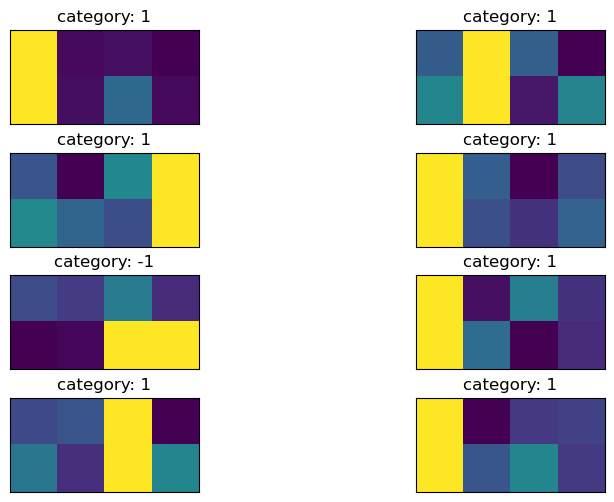

In [118]:
import matplotlib.pyplot as plt

# Make subplot titles so we can identify categories
titles = []
for i in range(8):
    title = "category: " + str(train_labels[i])
    titles.append(title)

# Generate a figure with nested images using subplots.
fig, ax = plt.subplots(4, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})

for i in range(8):
    ax[i // 2, i % 2].imshow(
        train_images[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
    ax[i // 2, i % 2].set_title(titles[i])
plt.subplots_adjust(wspace=0.1, hspace=0.3)

In [119]:
print(train_labels[:8])

[1, 1, 1, 1, -1, 1, 1, 1]


### 4. Step 1: Mapping the Problem to a Quantum Circuit

The core objective of a Variational Quantum Classifier (VQC) is to find a mathematical function $f$ with trainable parameters $\theta$ that correctly maps an input data vector (our 8-pixel image) $\vec{x}$ to its corresponding category ($\pm 1$).

#### The VQC Mathematical Model
The classification function is defined by the expectation value of an observable:
$$f_\theta(\vec{x}) = \langle 0 | U^\dagger(\vec{x}) W^\dagger(\theta) O W(\theta) U(\vec{x}) | 0 \rangle$$

#### Structural Components:
1. **Encoding Circuit $U(\vec{x})$:** Also known as the **Feature Map**. This circuit transforms classical data into a quantum state. For this implementation, we use the `ZFeatureMap` to keep the circuit depth low and efficient.
2. **Variational Circuit $W(\theta)$:** Also known as the **Ansatz**. This block contains tunable gates with parameters $\theta$. These parameters are adjusted by a classical optimizer to minimize classification errors.
3. **Observable $O$:** A quantum operator measured using the **Estimator primitive** to obtain the final classification result.



#### Flexibility of the Architecture:
It is important to note that QML is not restricted to a single "input" and "training" layer. One can interleave multiple encoding and variational layers (such as in **Data Re-uploading** schemes) depending on the complexity of the data and the technical requirements of the hardware.

In [120]:
from qiskit.circuit.library import z_feature_map

# One qubit per data feature
num_qubits = len(train_images[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
feature_map = z_feature_map(num_qubits, parameter_prefix="a")

### 5. Designing the Ansatz: Key Considerations

Selecting the right **Ansatz** (the variational circuit $W(\theta)$) is one of the most complex parts of QML. The choice is governed by three main factors:

#### 1. Hardware Constraints (Noise & Topology)
* **Depth vs. Noise:** Modern quantum computers are noisy. A circuit that is too "deep" (too many sequential gates) will lose its quantum information to decoherence before a measurement can be made.
* **Connectivity:** Qubits on a physical chip have a specific layout. Entangling qubits that are physically far apart requires **SWAP gates**, which significantly increases circuit depth and error rates.

#### 2. Problem-Specific Logic
* **Data Correlation:** In our case (horizontal/vertical lines), we should use our knowledge of the data. Since the patterns depend on the relationship between adjacent pixels, including **entanglement (CNOT gates)** between qubits that represent neighboring pixels is a strategic choice.
* **Quantum vs. Classical:** Always consider if a quantum circuit is truly the best tool for the task or if a classical algorithm could perform just as well.

#### 3. Optimization & The "Barren Plateau" Problem
* **Parameter Count:** More parameters ($\theta$) allow for more complexity but make the classical optimization slower and harder to converge.
* **Barren Plateaus:** This is a phenomenon where the "landscape" of the optimization becomes exponentially flat as the problem scales. This leads to **vanishing gradients**, making it nearly impossible for the optimizer to find the "valley" of minimum error.



#### Initial Approach:
We will begin with a simple ansatz to establish a baseline, then refine it later in the lesson to better capture the correlations of our pixel data.

5
2+ qubit depth: 3


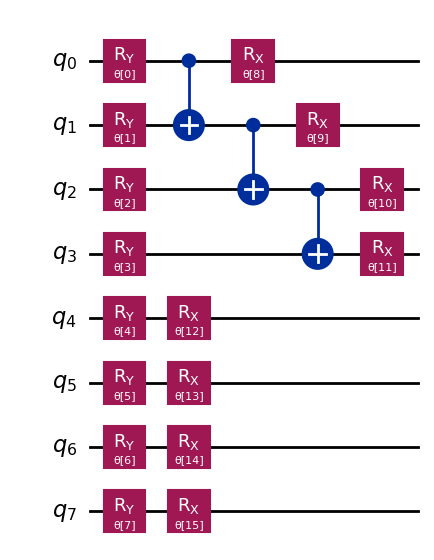

In [121]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
qnn_cnot_list = [[0, 1], [1, 2], [2, 3]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
qnn_circuit.draw("mpl")

#### Building the Full Architecture: The QNN Analogy

Now that we have both the **Data Encoding** ($U(\vec{x})$) and the **Variational Circuit** ($W(\theta)$) prepared, we combine them to form the complete architecture of our classifier.

#### The Neural Network Analogy
In this specific workflow, the components of our quantum circuit mirror the layers of a classical Neural Network:
* **Feature Map $U(\vec{x})$:** Acts like the **Input Layer**, loading the classical pixel values (the 8-pixel image) into the quantum Hilbert space.
* **Ansatz $W(\theta)$:** Acts like the **Hidden Layers**, containing the trainable "weights" or parameters ($\theta$) that the model adjusts to find patterns.

#### Nomenclature & Flexibility
Because this specific structure follows the classical "input-then-weights" flow, we often use the term **"QNN" (Quantum Neural Network)** in our code and variable names. 

**Important Note:** Do not let this analogy limit your design. Unlike classical networks, quantum circuits allow for unconventional data handling, such as interleaving encoding and variational layers or using entanglement to create correlations that have no direct classical equivalent.

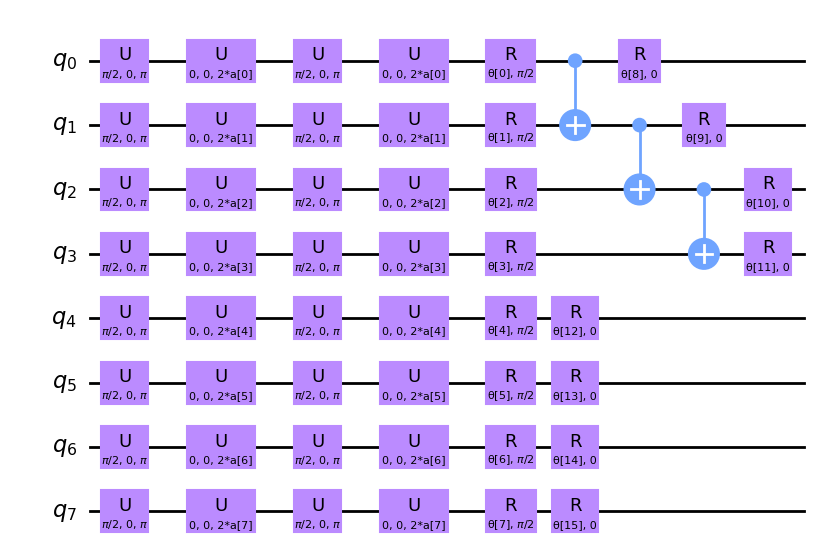

In [122]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

#### Defining the Observable for Binary Classification

To turn our quantum circuit into a classifier, we must define an **Observable ($O$)**. We use the **Estimator primitive** to calculate the expectation value of this operator, which serves as our model's prediction.

#### Why Choose the Pauli-Z Operator?
For this task, we apply a **$Z$ operator to each of the 8 qubits**. While other operators exist, $Z$ is the most natural choice for several reasons:
* **Binary Nature:** Classification is a binary task (Label -1 or +1), and the $Z$ operator has eigenvalues of exactly $\pm 1$.
* **Value Range:** The resulting expectation value falls within the interval $[-1, +1]$. This makes **0** a perfect "decision boundary" or cutoff value.
* **Hardware Efficiency:** Measuring in the Pauli-Z basis is the default for quantum hardware; it requires no additional gates, keeping the circuit depth as low as possible.

#### Information Processing Strategies:
When deciding which qubits to measure, there are two common approaches:
1. **Convolutional Layers:** Adding specific layers to "compress" information from many qubits down to a few (similar to Classical CNNs).
2. **Global Measurement:** Measuring an attribute from **every qubit** to ensure no data is lost. 

In this lesson, we opt for the second approach: we measure the $Z$ expectation value for every qubit to capture all relevant information from our 8-pixel image.

In [123]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

In [125]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

Loss function

Next, we need a loss function to calculate the difference between the predicted and calculated values of the labels. The function will take in the labels predicted by the algorithm and the correct labels and return the mean squared difference. There any many different loss functions. Here, MSE is an example that we chose.

In [126]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")

Let us also define a slightly different loss function that is a function of the variable parameters (weights), for use by the classical optimizer. This function only takes the ansatz parameters as input; other variables for the forward pass and the loss are set as global parameters. The optimizer will train the model by sampling different weights and attempting to lower the output of the cost/loss function.

In [127]:
def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

In [128]:
from scipy.optimize import minimize

In [129]:
# Globals
circuit = full_circuit
observables = observable
# input_params = train_images_batch
# target = train_labels_batch
objective_func_vals = []
iter = 0

### Qiskit Patterns Step 2: Optimize problem for quantum execution

We start by selecting a backend for execution. In this case, we will use the least-busy backend.

In [130]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-03-20 13:34:53,991: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-20 13:34:54,772: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-20 13:34:57,764: Using instance: open-instance, plan: open


ibm_fez


In [131]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

In [132]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

In [133]:
circuit_ibm = pm.run(full_circuit)
observable_ibm = observable.apply_layout(circuit_ibm.layout)

### Qiskit Patterns Step 3: Execute using Qiskit Primitives

Loop over the dataset in batches and epochs
We first implement the full algorithm using a simulator for cursory debugging and for estimates of error. We can now go over the entire dataset in batches in desired number of epochs to train our quantum neural network.

In [134]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0002309063537163
Iter: 50, loss: 0.9910034423915813


### Step 4: Post-process, return result in classical format

#### Testing and accuracy

We now interpret the results from training. We first test the training accuracy over the training set.




In [135]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[-1.07806742e-01  6.13858034e-02  4.88889517e-01 -5.41712363e-03
  2.31673659e-02 -6.35621634e-02 -2.93639980e-02 -1.16960293e-01
 -2.27045285e-01  3.47143847e-02 -4.34058731e-02  6.85959275e-02
  8.84012236e-04  2.27796482e-02 -3.47623501e-01  2.83825760e-02
 -3.47907576e-02 -1.45786585e-01 -4.69533007e-01 -1.82567961e-02
  1.28817243e-02 -1.21096334e-01 -3.91629501e-02 -3.22499359e-02
 -3.00525480e-03  3.64481144e-01  3.46037115e-02  5.12956201e-02
  4.50301723e-02  4.60529753e-03  4.05152080e-01 -8.78057641e-03
  6.60525998e-02  9.46294901e-02 -6.25719669e-02  3.41390986e-02
  2.40935012e-01  5.01122603e-02 -1.84654103e-02 -4.29890934e-01
 -2.89662767e-01  9.80257522e-02  1.74880477e-03  2.70065669e-02
  2.78388953e-01 -3.71069404e-01 -9.35074411e-03 -2.40493738e-02
  1.91052334e-02  6.61345076e-02  2.26706244e-03  2.32049920e-01
  6.98402216e-02 -2.75758526e-01  9.08902060e-03 -1.66811583e-02
  4.50958752e-03 -5.04659680e-02 -1.31891331e-03 -1.40589079e-02
 -1.07686363e-02  2.85093

The training accuracy is only  60
60, which is definitely not good. It is hard to imagine that the model's performance on the test set could be any better. Let's verify.

In [136]:
pred_test = forward(circuit, np.array(test_images), res["x"], estimator, observable)
# pred_test = forward(circuit_ibm, np.array(test_images), res['x'], estimator, observable_ibm)

print(pred_test)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test accuracy: {accuracy * 100}%")

[ 0.03490544  0.03185024 -0.03818344  0.25266111  0.00792563 -0.51590529
 -0.02111715 -0.15116484  0.04626771  0.02426528  0.04657796 -0.03113558
  0.02293938  0.19400836  0.00329491  0.03525167 -0.00349979 -0.1225299
  0.13400674  0.02368346  0.28452681  0.03545407 -0.00502367 -0.10460012
  0.10591551  0.06649062 -0.05393373 -0.02300524  0.0056465  -0.09439755
  0.06771526 -0.07226252 -0.10675784 -0.01806446  0.00150743  0.1720385
 -0.14832903  0.03214366 -0.05805016 -0.00734088 -0.08244864 -0.01978241
  0.16975198 -0.02933303 -0.0082598  -0.01845949  0.19266379  0.17243566
 -0.02712035  0.02130188 -0.25076566  0.0100313  -0.10234677 -0.09672355
  0.04818503 -0.01241683  0.2933495  -0.02171279 -0.00102982 -0.01206131]
[ 1.  1. -1.  1.  1. -1. -1. -1.  1.  1.  1. -1.  1.  1.  1.  1. -1. -1.
  1.  1.  1.  1. -1. -1.  1.  1. -1. -1.  1. -1.  1. -1. -1. -1.  1.  1.
 -1.  1. -1. -1. -1. -1.  1. -1. -1. -1.  1.  1. -1.  1. -1.  1. -1. -1.
  1. -1.  1. -1. -1. -1.]
[-1, -1, 1, 1, -1, -1, 1, 

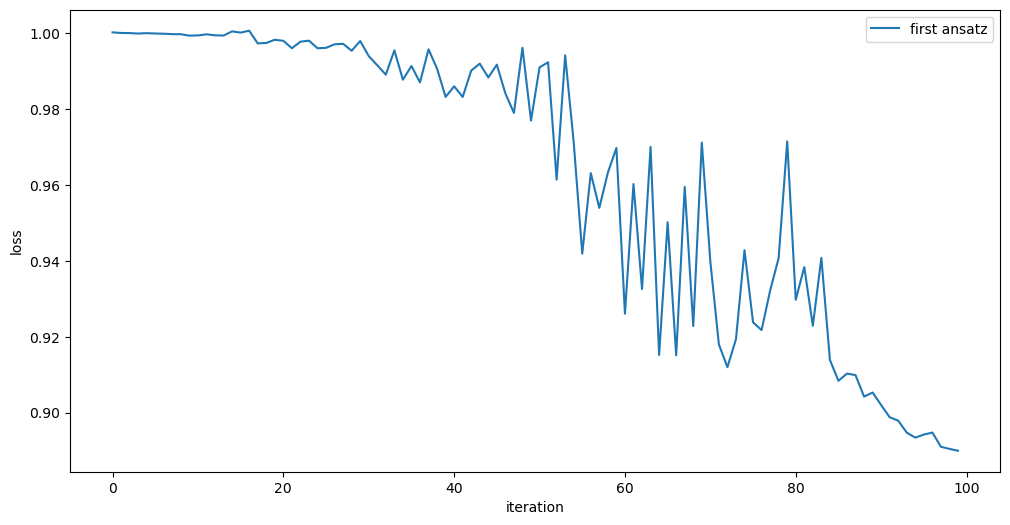

In [137]:
obj_func_vals_first = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_first, label="first ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

In [138]:
missed = []
for i in range(len(test_labels)):
    if pred_test_labels[i] != test_labels[i]:
        missed.append(test_images[i])
print(len(missed))

24


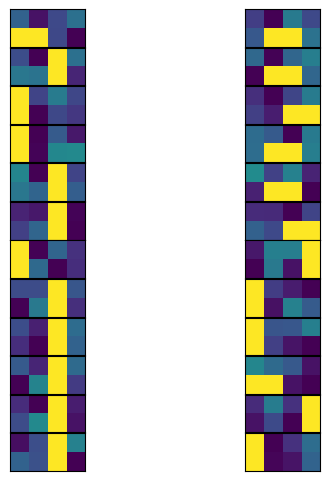

In [139]:
fig, ax = plt.subplots(12, 2, figsize=(6, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(len(missed)):
    ax[i // 2, i % 2].imshow(
        missed[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
plt.subplots_adjust(wspace=0.02, hspace=0.025)

## Improving the model

Quantum Circuit Mapping for Image Classification

#### 1. Problem Definition & Feature Mapping
When mapping an image classification problem to a quantum circuit, the **topology of the circuit** (how qubits are connected) must reflect the physical structure of the pixels. To identify patterns like horizontal or vertical lines, we must analyze the correlation between adjacent pixels.

## 2. Detection Logic: Horizontal vs. Vertical
The goal is to determine the relationship between neighbor pixels:
* **Horizontal Detection:** We ask, *"If pixel $i$ is yellow, is pixel $i+1$ also yellow?"* for all pixels across a row.
* **Vertical Detection:** We compare pixels in the same column across different rows (e.g., pixel 0 and pixel 4).
* **Binary Classification Shortcut:** Since the classification is binary, the circuit can be simplified. If the circuit is trained to reliably detect a horizontal line and *fails* to find one, the image can be classified as a vertical line by default.

## 3. Qubit Connectivity & CNOT Gates
CNOT gates are used to create **entanglement** between qubits, allowing the circuit to "sense" the state of one pixel relative to another.

### Circuit Evolution:
* **Initial State:** CNOT gates were only placed between qubits **0-1, 1-2, and 2-3**. 
    * *Limitation:* This only monitors the top row and ignores the rest of the image.
* **Proposed Optimization:**
    * Add CNOT gates between qubits **4-5, 5-6, and 6-7** to fully cover the bottom row.
    * Consider adding vertical CNOTs (e.g., **0-4 or 2-6**) if horizontal detection alone is insufficient.

## 4. Key Takeaway for Variational Circuits
The placement of entangling gates (like CNOTs) is not arbitrary. In Quantum Machine Learning (QML), these gates act as the "filters" of a convolutional neural network, and their placement must correspond to the **spatial features** we want the model to learn.

5
2+ qubit depth: 3


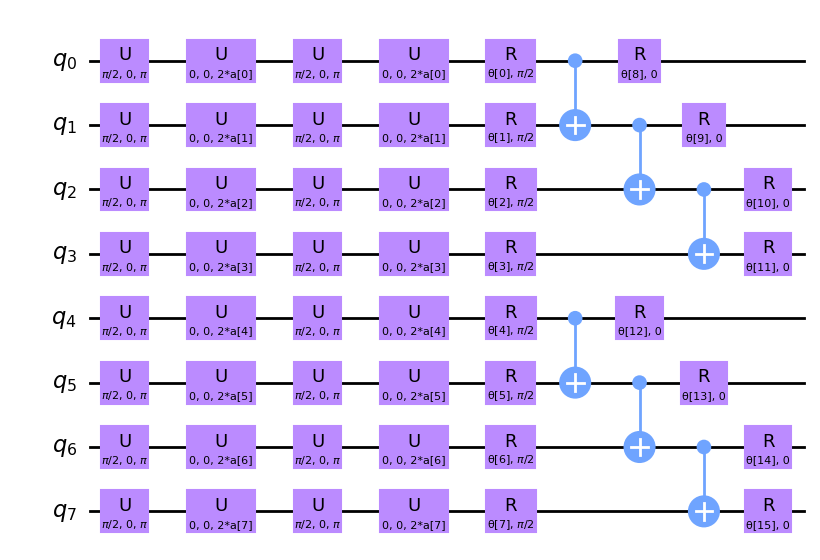

In [140]:
# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Here is an extended list of qubit pairs between which we want CNOT gates. This now covers all pixels connected by horizontal lines.
qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Combine the feature map and variational circuit
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

applying model to train data

In [142]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0049762969140237
Iter: 50, loss: 0.9610166111578137


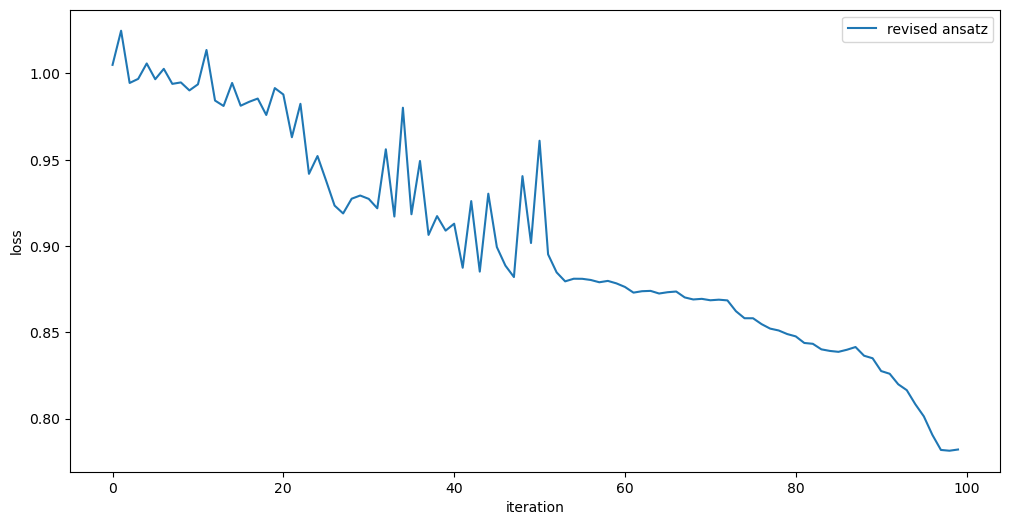

In [143]:
obj_func_vals_revised = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_revised, label="revised ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

In [144]:
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[ 0.17588365  0.06358946  0.03154715  0.40568015 -0.26663654  0.35052378
  0.32532118  0.42179424 -0.12503935  0.01735073  0.34210006  0.03982966
  0.22643087 -0.4412831  -0.08404207 -0.21145139 -0.0864077  -0.08422211
  0.1610014   0.16197725  0.40828044 -0.14028519  0.12610441  0.33568985
 -0.21658925  0.14599275  0.2047188   0.27508696  0.38082561 -0.07229336
  0.01794865  0.29048418 -0.10297829  0.12442964  0.38024615  0.17366051
  0.06349612  0.27704119 -0.13239334 -0.02905743  0.03690951  0.18908208
  0.31179867 -0.45557033  0.0577176  -0.10626097  0.28010561  0.23700008
 -0.16567916  0.15686607  0.12601319  0.23702745  0.12737872 -0.14154204
  0.13267215  0.39800623  0.03006156  0.46442971 -0.21106578 -0.34238585
 -0.10174681  0.21789043  0.08702818 -0.1833671   0.32475031  0.2210001
  0.38867033 -0.10543421  0.09170983  0.45790369  0.09308404  0.2297307
  0.38493105  0.3522148  -0.03609128  0.0977109   0.20883459  0.07064556
  0.18794959  0.16861158  0.30113559  0.45925807  0.4

In [145]:
pred_test = forward(circuit, np.array(test_images), res["x"], estimator, observable)
# pred_test = forward(circuit_ibm, np.array(test_images), res['x'], estimator, observable_ibm)

print(pred_test)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test accuracy: {accuracy * 100}%")

[ 0.15991126 -0.38271809  0.16161486  0.04462364 -0.22646557 -0.0807667
  0.47175973  0.00123989  0.09548693 -0.29120313  0.02120809  0.2205051
  0.27667248  0.01682459 -0.16974311  0.1939437  -0.36231285  0.1744752
  0.36515602  0.17900844  0.14718311 -0.11755908  0.07757464  0.2714839
  0.01625922 -0.29012097  0.33790635  0.03022243  0.35925687  0.25999274
  0.14048379 -0.25958896  0.08768122  0.33258691  0.06325939  0.31244923
  0.20687033  0.10872432  0.30611549 -0.23099417  0.03384005 -0.18916946
  0.04495479  0.49401586  0.18620635 -0.10690734  0.12783912  0.25469493
  0.26001136  0.22831741  0.1465171   0.08602245  0.19535164  0.02265729
  0.15900032  0.30678305  0.05103284  0.39003678 -0.25936609  0.29612062]
[ 1. -1.  1.  1. -1. -1.  1.  1.  1. -1.  1.  1.  1.  1. -1.  1. -1.  1.
  1.  1.  1. -1.  1.  1.  1. -1.  1.  1.  1.  1.  1. -1.  1.  1.  1.  1.
  1.  1.  1. -1.  1. -1.  1.  1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1. -1.  1.]
[-1, -1, 1, 1, -1, -1, 1, -1

### **Experiment Results & Analysis**

**Observed Accuracy:** 83.33%  
**Reference Accuracy (IBM Course):** 100%

#### **Technical Analysis of the Discrepancy:**
The 17% difference in accuracy compared to the course material can be attributed to several factors inherent in Variational Quantum Algorithms (VQA):

1. **Local Minima (COBYLA):** Since the initial weights were assigned randomly using `np.random.seed(42)`, the COBYLA optimizer likely converged to a local minimum rather than the global optimum.
2. **Circuit Topology (Ansatz):** The current circuit layout might lack the specific entangling gates (CNOTs) required to detect patterns in the lower row (qubits 4-7). Without these correlations, the model cannot "see" horizontal features in the bottom half of the image.
3. **Optimization Constraints:** The `maxiter=100` limit might have truncated the optimization process before the cost function reached its absolute minimum.

#### **Next Steps for Optimization:**
* Increase `maxiter` to 250 to allow for deeper convergence.
* Update the `ansatz` to include CNOT gates between qubits **4-5, 5-6, and 6-7**.
* Experiment with different random seeds for weight initialization.

5
2+ qubit depth: 3


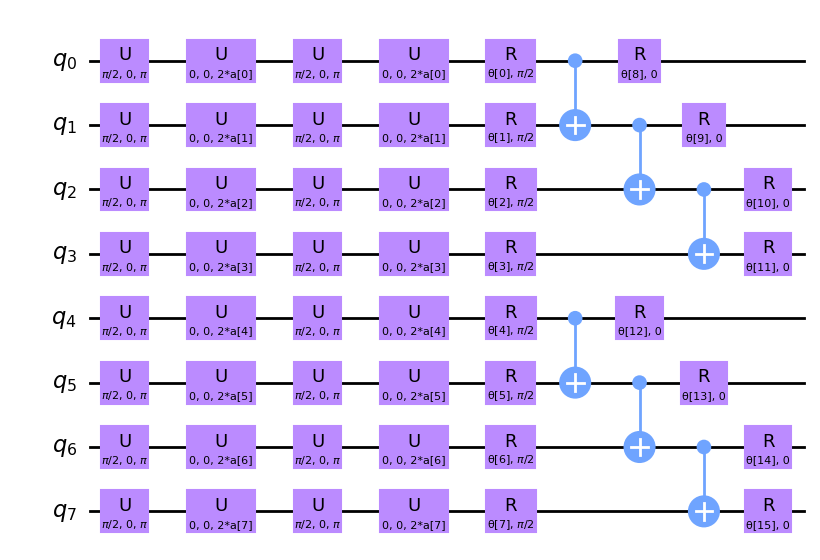

In [147]:
# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Here is an extended list of qubit pairs between which we want CNOT gates. This now covers all pixels connected by horizontal lines.
qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Combine the feature map and variational circuit
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

In [148]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0049762969140237
Iter: 50, loss: 0.9610166111578137


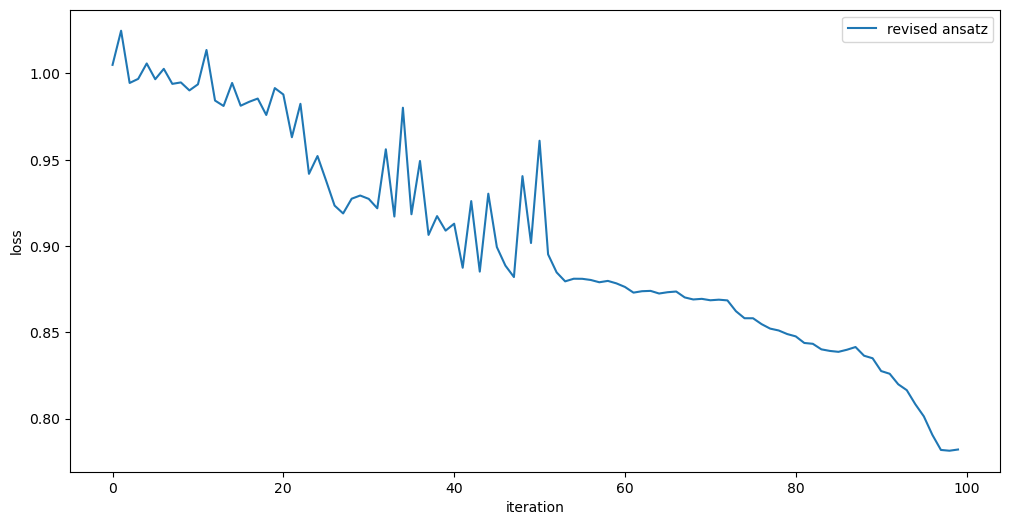

In [149]:
obj_func_vals_revised = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_revised, label="revised ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

In [150]:
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[ 0.17588365  0.06358946  0.03154715  0.40568015 -0.26663654  0.35052378
  0.32532118  0.42179424 -0.12503935  0.01735073  0.34210006  0.03982966
  0.22643087 -0.4412831  -0.08404207 -0.21145139 -0.0864077  -0.08422211
  0.1610014   0.16197725  0.40828044 -0.14028519  0.12610441  0.33568985
 -0.21658925  0.14599275  0.2047188   0.27508696  0.38082561 -0.07229336
  0.01794865  0.29048418 -0.10297829  0.12442964  0.38024615  0.17366051
  0.06349612  0.27704119 -0.13239334 -0.02905743  0.03690951  0.18908208
  0.31179867 -0.45557033  0.0577176  -0.10626097  0.28010561  0.23700008
 -0.16567916  0.15686607  0.12601319  0.23702745  0.12737872 -0.14154204
  0.13267215  0.39800623  0.03006156  0.46442971 -0.21106578 -0.34238585
 -0.10174681  0.21789043  0.08702818 -0.1833671   0.32475031  0.2210001
  0.38867033 -0.10543421  0.09170983  0.45790369  0.09308404  0.2297307
  0.38493105  0.3522148  -0.03609128  0.0977109   0.20883459  0.07064556
  0.18794959  0.16861158  0.30113559  0.45925807  0.4

## Scaling and running on real quantum computers

In [151]:
# This code defines the images to be classified:

import numpy as np

# Total number of "pixels"/qubits
size = 36
# One dimension of the image (called vertical, but it doesn't matter). Must be a divisor of `size`
vert_size = 6
# The length of the line to be detected (yellow). Must be less than or equal to the smallest dimension of the image (`<=min(vert_size,size/vert_size)`
line_size = 6


def generate_dataset(num_images):
    images = []
    labels = []
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    # Make two adjacent entries pi/2, then move down to the next row. Careful to avoid the "pixels" at size/vert_size - linesize, because we want to fold this list into a grid.

    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

    # Make entries pi/2, spaced by the length/rows, so that when folded, the entries appear on top of each other.

    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))
            # Randomly select one of the several rows you made above.
        elif rng == 1:
            labels.append(1)
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))
            # Randomly select one of the several rows you made above.

        # Create noise
        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
    return images, labels


hor_size = round(size / vert_size)

In [152]:
from sklearn.model_selection import train_test_split

np.random.seed(42)
# Here we specify a very small data set. Increase for realism, but monitor use of quantum computing time.
images, labels = generate_dataset(10)

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

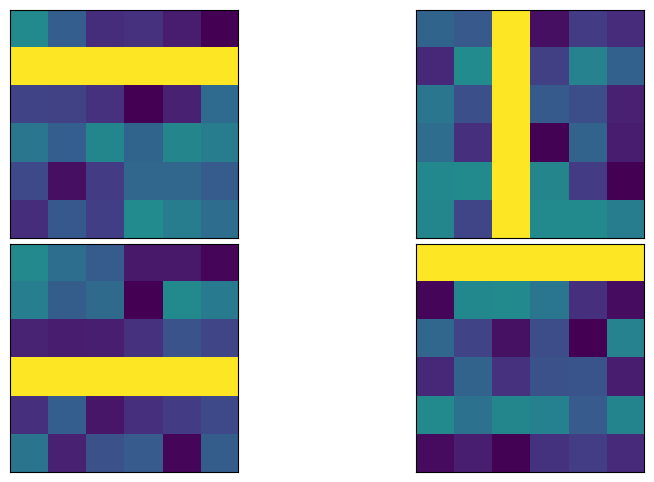

In [153]:
import matplotlib.pyplot as plt

# Generate a figure with nested images using subplots.

fig, ax = plt.subplots(2, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(4):
    ax[i // 2, i % 2].imshow(
        train_images[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
plt.subplots_adjust(wspace=0.1, hspace=0.025)

### Step 1: Map the problem to a quantum circuit

In [154]:
from qiskit.circuit.library import z_feature_map

# One qubit per data feature
num_qubits = len(train_images[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
feature_map = z_feature_map(num_qubits, parameter_prefix="a")

In [155]:
# This creates a circuit with the cxs in the compressed order.

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

qnn_circuit = QuantumCircuit(size)
params = ParameterVector("θ", length=2 * size)
for i in range(size):
    qnn_circuit.ry(params[i], i)

# CNOT gates between horizontally adjacent qubits.
for i in range(vert_size):
    for j in range(hor_size):
        if j < hor_size - 1:
            qnn_circuit.cx((i * hor_size) + j, (i * hor_size) + j + 1)

# CNOT gates between vertically adjacent qubits, likely not necessary based on our preliminary simulation.
#        if i<vert_size-1:
#            qnn_circuit.cx((i*hor_size)+j,(i*hor_size)+j+hor_size)
for i in range(size):
    qnn_circuit.rx(params[size + i], i)
qnn_circuit_large = qnn_circuit

print(qnn_circuit_large.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit_large.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)
# qnn_circuit_large.draw()

7
2+ qubit depth: 5


In [156]:
# Combine the feature map and variational circuit
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Check the depth of the full circuit
print(full_circuit.decompose().depth())
print(
    f"2+ qubit depth: {full_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

11
2+ qubit depth: 5


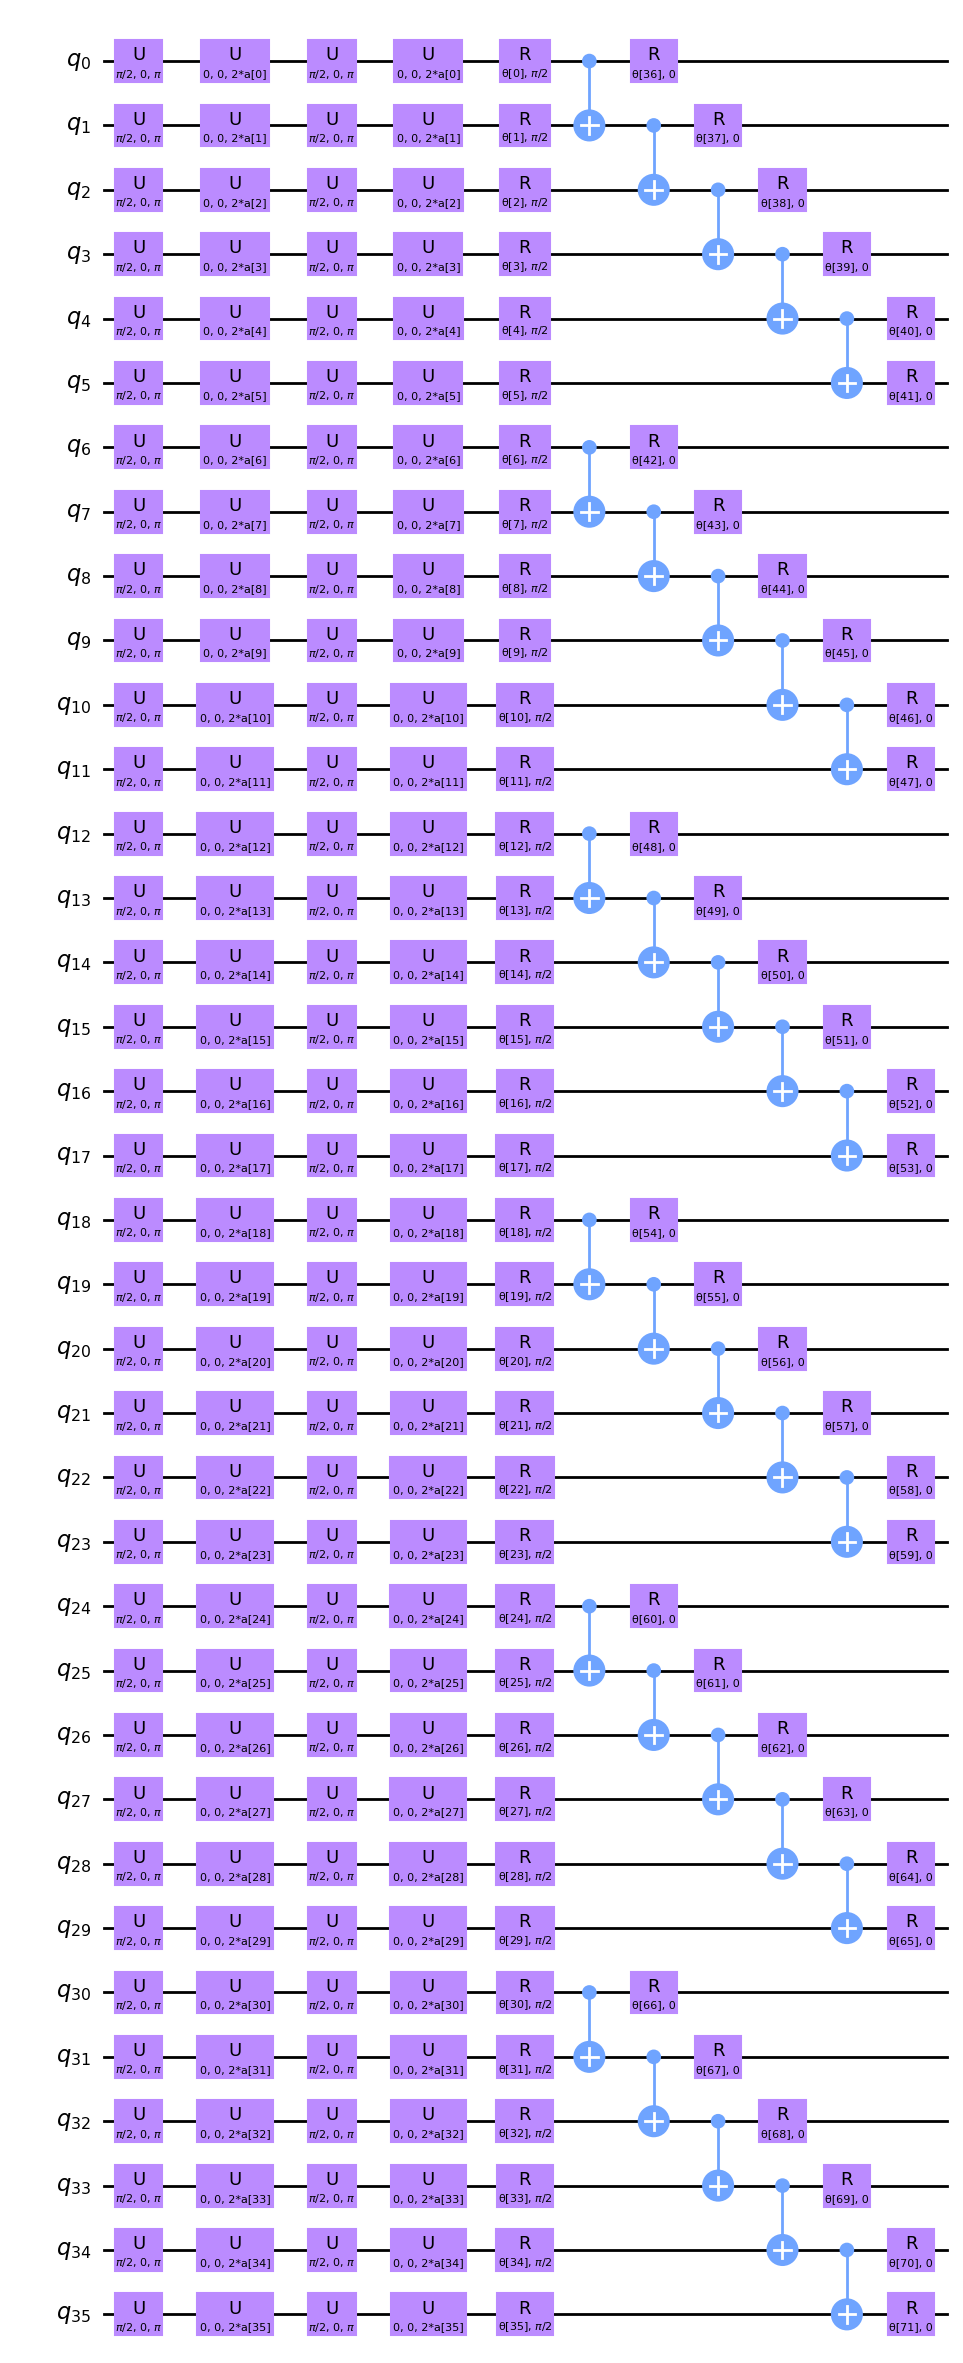

In [157]:
full_circuit.decompose().draw("mpl", style="clifford", idle_wires=False, fold=-1)

We also need to re-define our observable with our larger images:

In [158]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

## Qiskit Patterns Step 2: Optimize problem for quantum execution

In [159]:
from qiskit_ibm_runtime import QiskitRuntimeService

# To run on hardware, select the least busy quantum computer or specify a particular one.
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
# backend = service.backend("ibm_brisbaneane")

print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-03-21 12:24:12,527: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-21 12:24:13,165: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-21 12:24:16,067: Using instance: open-instance, plan: open


ibm_fez


In [160]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

In [161]:
# Try pass manager several times, since heuristics can return various transpilations on large circuits, and we want the shallowest.

transpiled_qcs = []
transpiled_depths = []
transpiled_2q_depths = []
for i in range(1, 10):
    circuit_ibm = pm.run(full_circuit)
    transpiled_qcs.append(circuit_ibm)
    transpiled_depths.append(circuit_ibm.decompose().depth())
    transpiled_2q_depths.append(
        circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)
    )
    # print(i)

print(transpiled_depths)
print(transpiled_2q_depths)

# Use the shallowest

minpos = transpiled_2q_depths.index(min(transpiled_2q_depths))

[57, 57, 57, 57, 57, 57, 57, 57, 57]
[5, 5, 5, 5, 5, 5, 5, 5, 5]


In [162]:
circuit_ibm = transpiled_qcs[2]
observable_ibm = observable.apply_layout(circuit_ibm.layout)
print(circuit_ibm.decompose().depth())
print(
    f"2+ qubit depth: {circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

57
2+ qubit depth: 5


## Qiskit Patterns Step 3: Execute using Qiskit Primitives